# Paper Plots

## Imports

In [1]:
import time
_notebook_start = time.time()

import numpy as np
import emcee

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm, Normalize
import matplotlib.ticker as ticker
from matplotlib.ticker import LogFormatterSciNotation
from mpl_toolkits.axes_grid1 import ImageGrid

from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
import corner

from astropy import units as u
from astropy import constants
from astropy.units import Quantity

import scipy
from scipy import signal
from scipy.fft import fft, fftshift

import sys

import cmcrameri.cm as cmc
import corner
from tqdm import tqdm

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr
from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Configuration

Set all user-facing parameters here.

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # results for all cases
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                        # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'             # output directory

# ── Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['low_dl_fr_0', 'high_dl_fr_0', 'low_dl_fr_20', ]  # sub-folder names under result_dir

nm_list_arr = [
    [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
    [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
    [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
]

dl_inds = [[3, 4, 5, 6], [10, 11, 12, 13], [3, 3, 3, 3]]  # delay indices per case (for DPS plots)

# ── Single-case selection (for Figures 5, 6, 7, 8, 9) ────────────────────────
case_idx = 2  # 0 = Case I, 1 = Case II, 2 = Case III

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes = 10   # number of foreground modes

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 100000  # number of Gibbs iterations
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn         = 10      # burn-in (%)

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Derived parameters

In [3]:
# freqs = np.linspace(100., 120., 120)[:Nfreqs]  # MHz
# lsts  = np.linspace(0., 1., Ntimes)            # hours

freqs = np.load(parent_dir+'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6
lsts = np.load(parent_dir+'res/npy_data/lsts_full.npy')[:Ntimes]

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                               # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                 # DLFR(1); linearity: DLFR(1+x) = dlfr_ones + DLFR(x)

# Systematics operator for the selected case
sys_modes_operator = sys_modes(
    freqs_Hz   = freqs * 1e6,
    times_sec  = lsts_sec,
    modes      = nm_list_arr[case_idx],
)

3 20
4 20
5 20
6 20


## Helper functions

In [4]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, labels=None, truths=None, burn=0, thin=1, fig=None,
    truths_label="Truth",
    extra_truths=None, extra_color="tab:green", extra_truths_label="Truth B",
    title=None, legend_loc="best",
    nsigma=3,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, labels=labels, truths=truths,
        truth_color="tab:red",
        quantiles=quantiles,
        levels=levels,
        fig=fig,
        show_titles=True, title_fmt=".3g",
        bins=100, smooth=2.0, color="C0",
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]
    legend_handles = []
    if truths is not None:
        legend_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        legend_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if legend_handles:
        ax0.legend(handles=legend_handles, loc=legend_loc, frameon=False)
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

## Plot specifications

In [5]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 34})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', "#ff8fba"]
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# Tick helpers (frequency / delay-fringe-rate space)
freqs_mhz = freqs * u.MHz
xticklocs = [1, 10, 20, 30, 40, 50, 59]
yticklocs = [0, 10, 20, 30, 40, 50, 60, 70]

lsts_round   = np.array([round(l, 2) for l in lsts])
times        = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3  # mHz

xticks_dl   = delays[xticklocs]
yticks_fr   = fringe_rates[yticklocs]
xticklabels_dl = [str(int(round(val, 2))) for val in xticks_dl.value]
yticklabels_fr = [f'{val:.2f}' for val in yticks_fr]

---
# Figure 1: Data in visibility space

In [6]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-fgs.uvh5')
clean_vis  = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

uvd = UVData()
uvd.read(parent_dir + 'res/vis_corrupted_test.uvh5')
vis_corr   = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

# Tick setup for full-resolution arrays
freqs_mhz_full = freqs_full * u.MHz
times_full     = Quantity(lsts_full * 12 / np.pi, unit='h')
xticklocs_full = [1, 20, 40, 60, 80, 100, 119]
yticklocs_full = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
xticklabels_freqs_full = [str(int(val * 10e-7)) for val in freqs_mhz_full[xticklocs_full].value]
yticklabels_times_full = [str(round(val, 2))    for val in times_full[yticklocs_full].value]

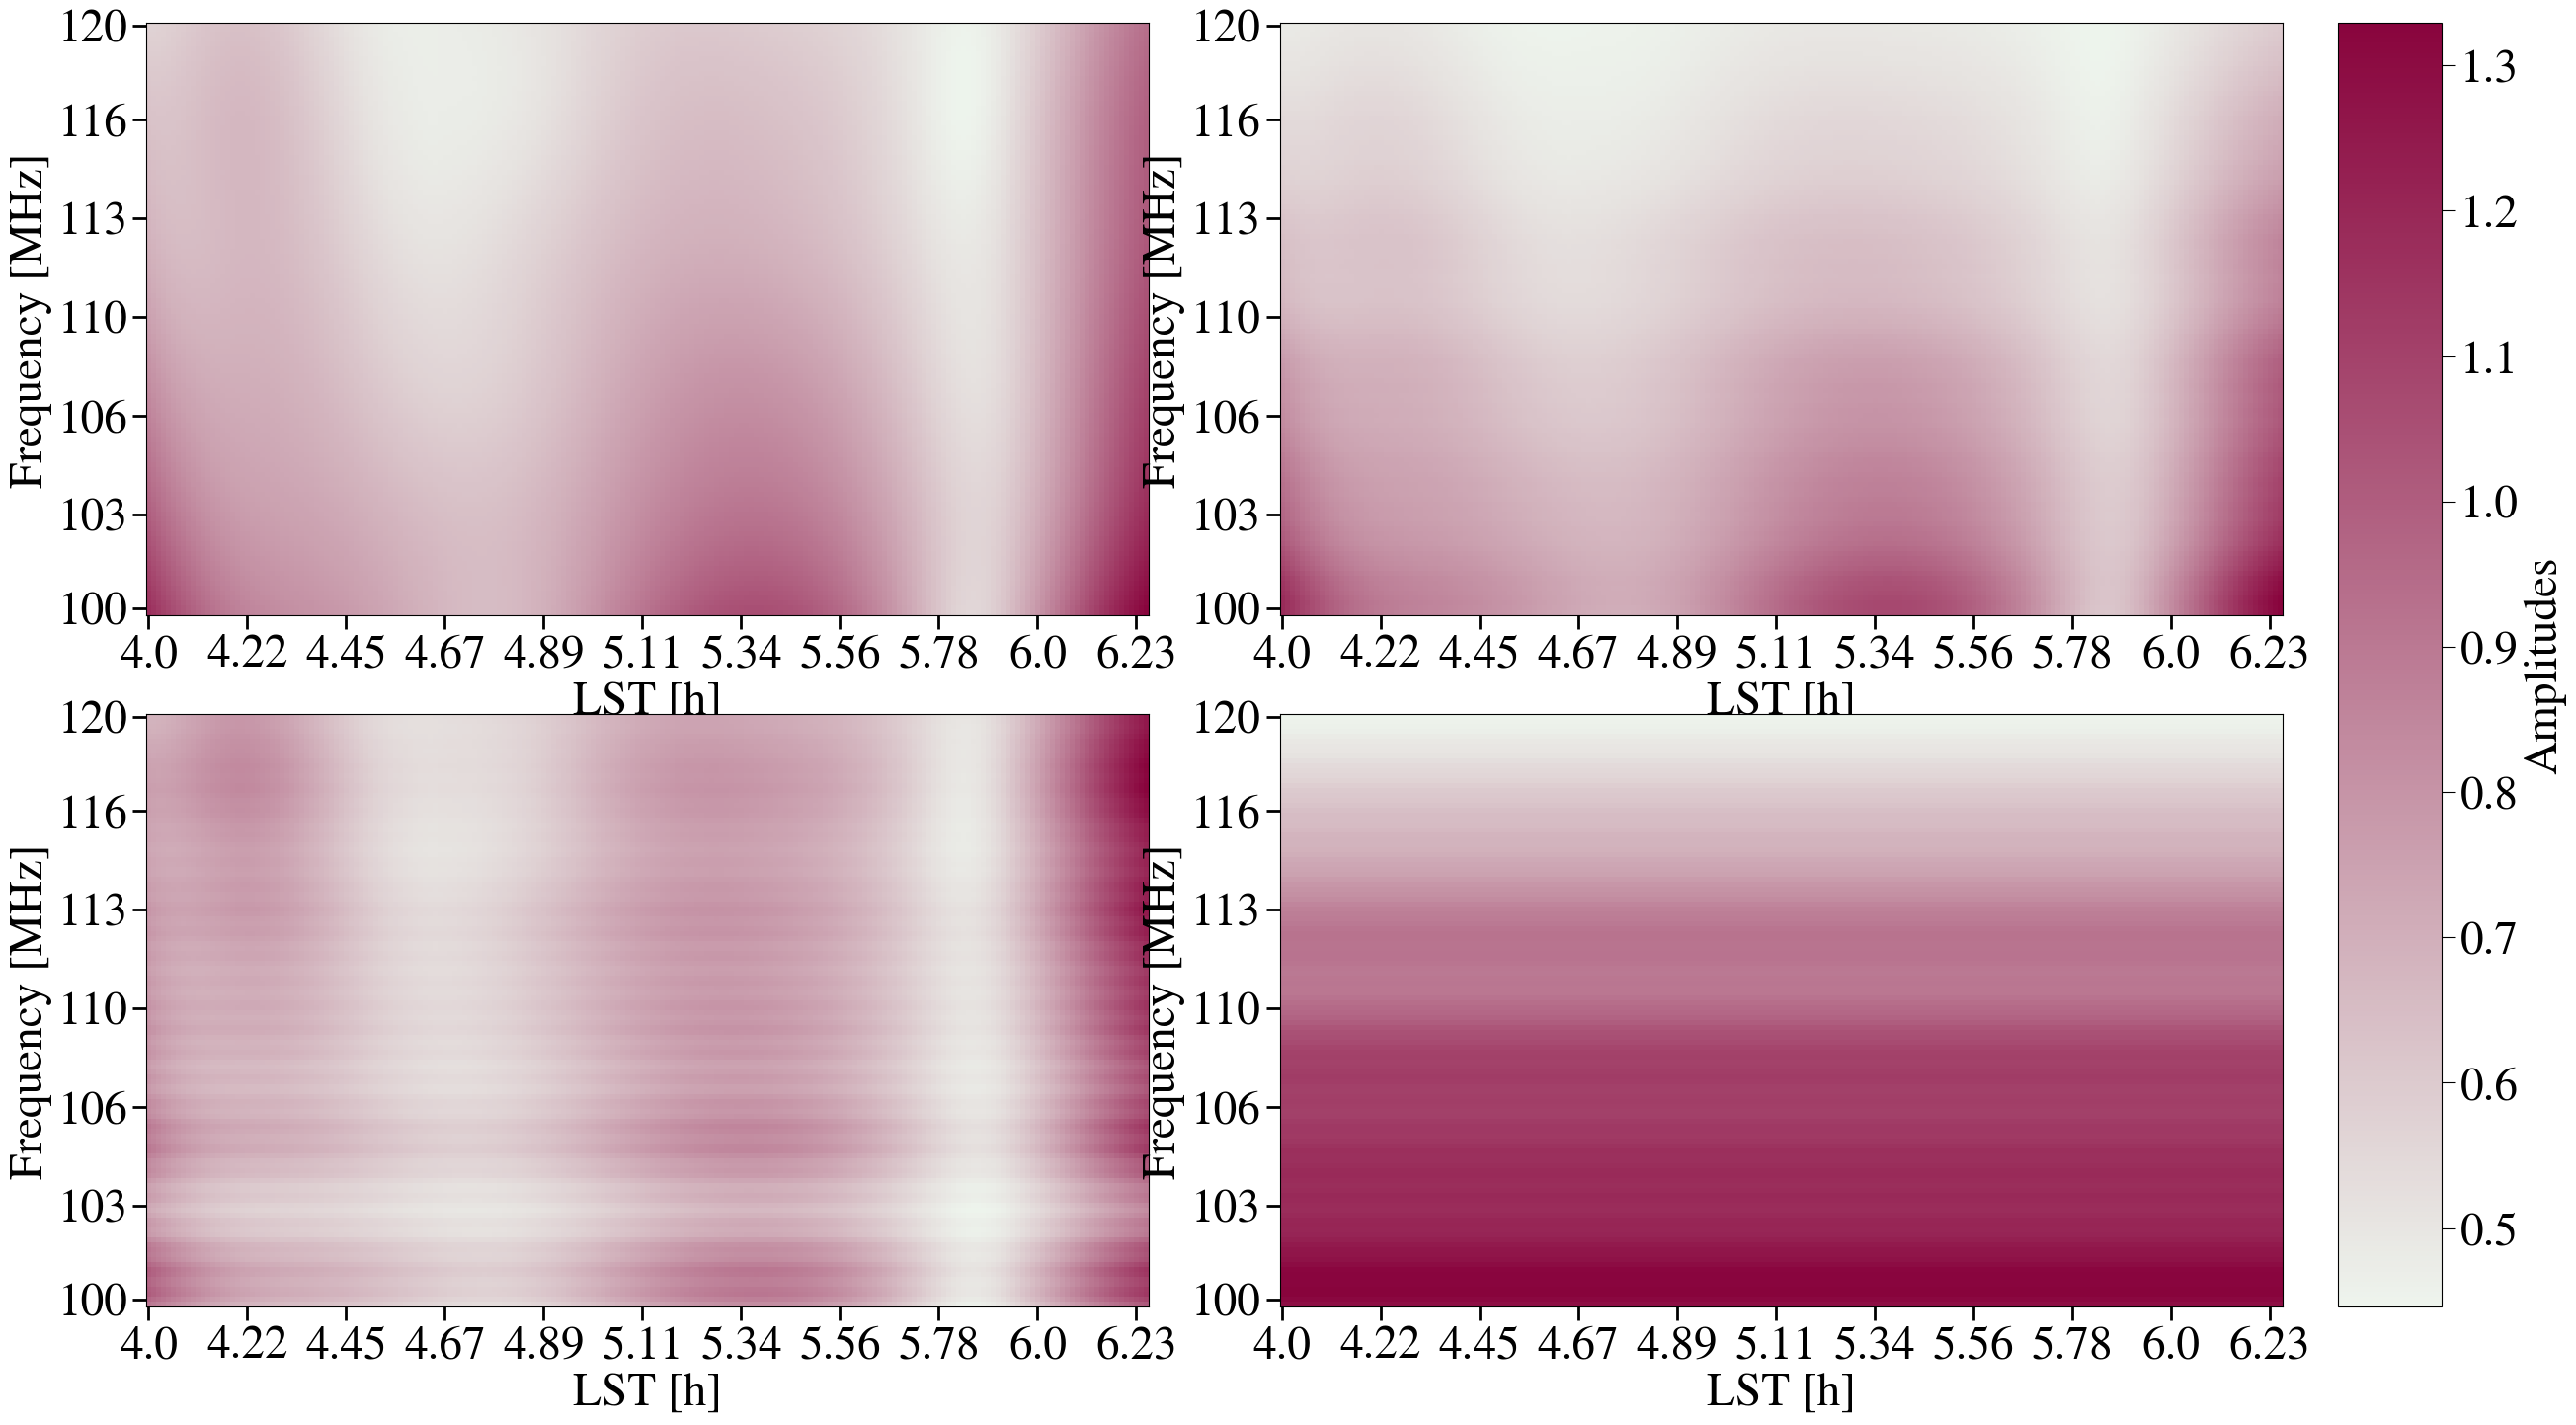

In [7]:
fig = plt.figure(figsize=(30., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.78, 0.65),
    nrows_ncols=(2, 2),
    axes_pad=1,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='all',
    aspect=False,
)
data_arr = np.array([[clean_vis, vis_corr], [vis_corr - clean_vis, vis_corr / clean_vis]])
a = 0
for i in range(2):
    for j in range(2):
        im = axs[a].imshow(np.abs(data_arr[i, j, :, :]).T, cmap=paper_map_pink, origin='lower')
        axs[a].set_ylabel('Frequency [MHz]')
        axs[a].set_xlabel('LST [h]')
        axs[a].tick_params(direction='out', length=6, width=2, colors='black', size=10)
        a += 1
cbar = axs.cbar_axes[0].colorbar(im, label='Amplitudes')
cbar.ax.tick_params(which='both', color='black', labelcolor='black', size=10)
for a in axs:
    a.set_yticks(xticklocs_full, labels=xticklabels_freqs_full)
    a.set_xticks(yticklocs_full, labels=yticklabels_times_full)
# plt.savefig(fig_dir + '/systematics_in_vis_space.pdf', bbox_inches='tight', dpi=300)

---
# Figure 3: Test cases in delay–fringe-rate space

In [8]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

eor_true = np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true  = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_full      = eor_true + fg_true
data_true_dlfr_full = dlfr(data_true_full)

3 0
4 0
5 0
6 0
10 0
11 0
12 0
13 0
3 20
4 20
5 20
6 20


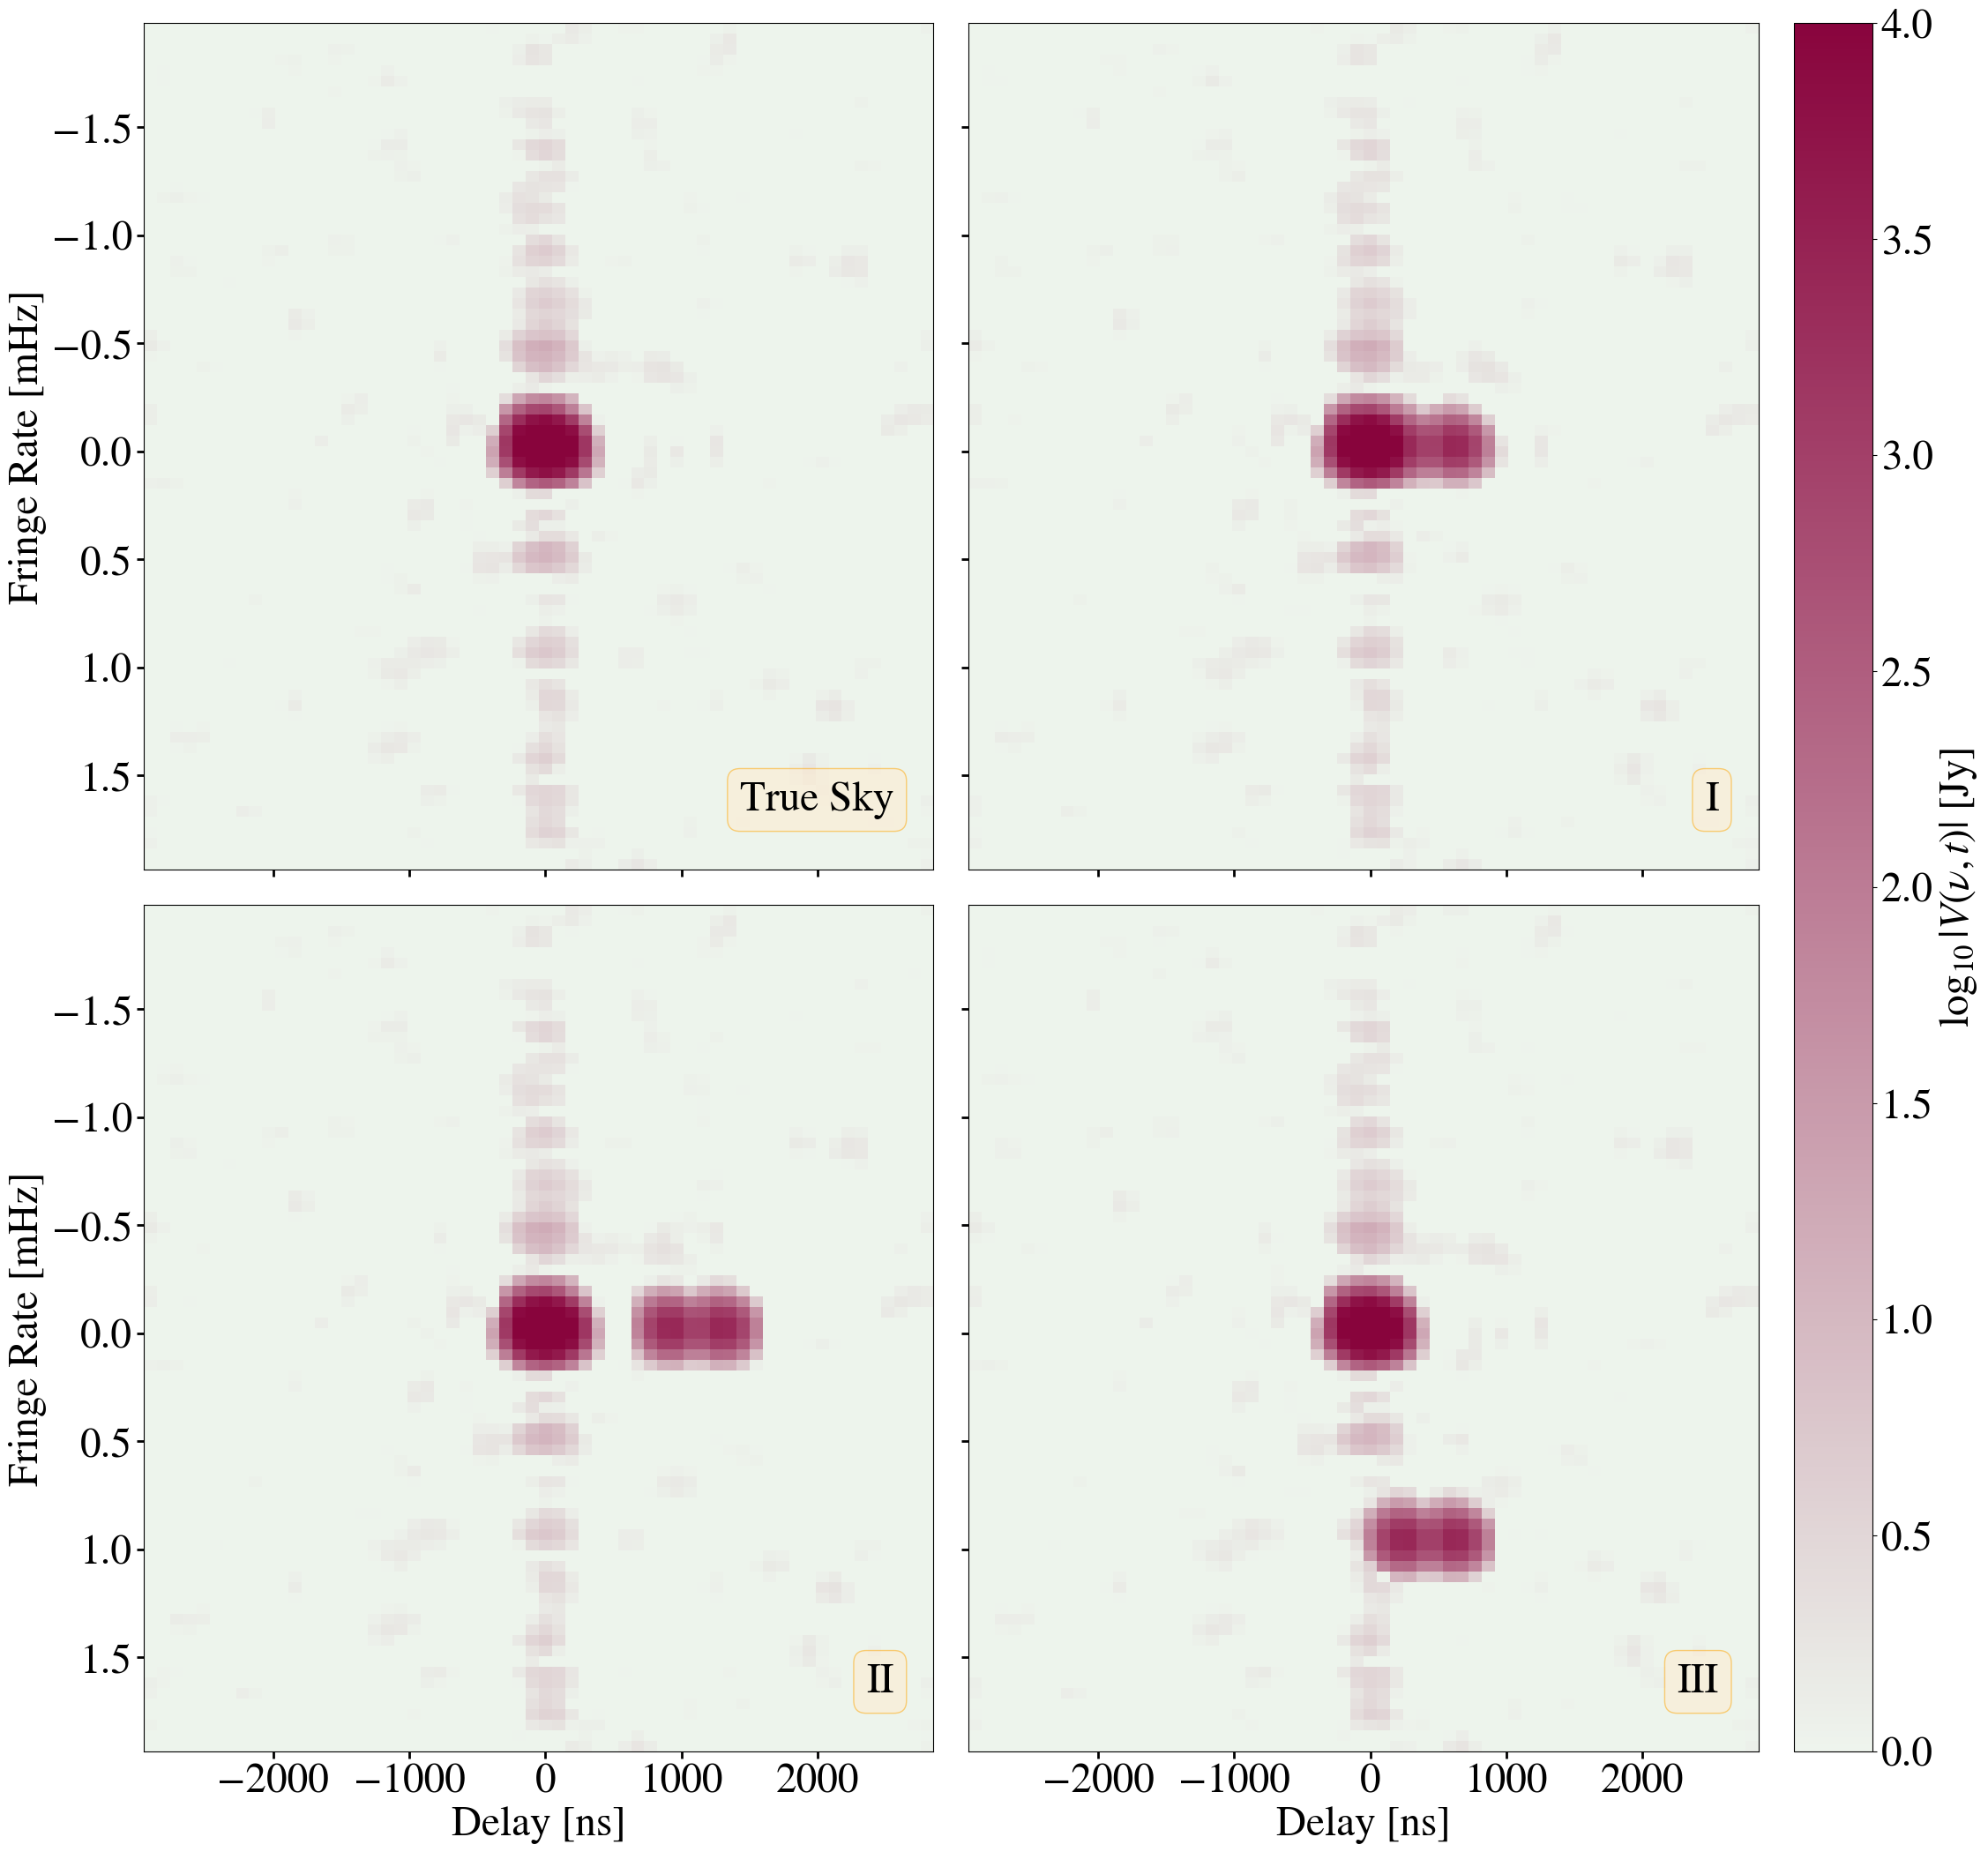

In [9]:
fig = plt.figure(figsize=(20., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 2),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls_from_dlfr(
    data_true_dlfr_full, freqs * 1e6, lsts, fig=fig, ax=axs[0], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all',
    baseline=None, horizon_color='magenta', colorbar_flag=False,
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

fig_labels = ['I', 'II', 'III']
for i, run_version in enumerate(run_version_arr):
    op = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[i])
    sys_model_true = (1 + op @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
    total_data_dlfr = dlfr(sys_model_true * data_true_full)
    plot_op = plot_waterfalls_from_dlfr(
        total_data_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs[i + 1], mode='log',
        vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=False,
        baseline=None, horizon_color='magenta',
    )
    axs[i + 1].text(0.95, 0.07, fig_labels[i], bbox=bbox, transform=axs[i + 1].transAxes, horizontalalignment='right')

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|V(\nu, t)|$ [Jy]')
plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)

---
# Single-case analysis (case_idx = `case_idx`)

The cells below load and process data for the single case selected by `case_idx`.

In [10]:
run_version = run_version_arr[case_idx]

fg_true        = np.load(result_dir + run_version + '/fg_true.npy')
fgmodes        = np.load(result_dir + run_version + '/fgmodes.npy')
fg_amps_gcr    = np.load(result_dir + run_version + '/fg-amps.npy')
eor_true       = np.load(result_dir + run_version + '/eor_true.npy')
eor_gcr        = np.load(result_dir + run_version + '/gcr-eor.npy')
ps_sample      = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post        = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr      = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
data_true      = np.load(result_dir + run_version + '/data_true.npy')

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# ── Static DLFR quantities ────────────────────────────────────────────────────
sky_true_dlfr       = dlfr(sky_true)
sys_model_true_dlfr = dlfr(sys_model_true)
delta_g_dlfr_true   = dlfr(delta_g_true)
data_true_dlfr      = dlfr(data_true)

# ── Allocate per-iteration arrays (only those needed after the loop) ──────────
ps_fg    = np.empty(ps_sample.shape)
ps_sys   = np.empty(ps_sample.shape)
ps_del_g = np.empty(ps_sample.shape)
ps_data  = np.empty(ps_sample.shape)

sky_dlfr_arr     = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 5 std
fg_dlfr_arr      = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 11 Pearson
delta_g_dlfr_arr = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 6 stats + Fig 11 Pearson

# ── Single-pass Gibbs sample processing ──────────────────────────────────────
print('Processing samples (single case)...')
for i in tqdm(range(Niter)):
    fg_vis = (fgmodes @ fg_amps_gcr[i].T).T
    dg     = (sys_modes_operator @ b_sys_gcr[i]).reshape([Nfreqs, Ntimes]).T
    dg_d   = dlfr(dg)

    ps_fg[i]    = calc_ps((fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i].T).T)
    ps_sys[i]   = calc_ps(1 + dg)
    ps_del_g[i] = calc_ps(dg)
    ps_data[i]  = calc_ps((1 + dg) * (eor_gcr[i] + fg_vis))

    sky_dlfr_arr[i]     = dlfr(eor_gcr[i] + fg_vis)
    fg_dlfr_arr[i]      = dlfr(fg_vis)
    delta_g_dlfr_arr[i] = dg_d

# ── Power spectrum statistics ─────────────────────────────────────────────────
eor_pspec_avg   = np.mean(ps_sample, axis=0)
fg_pspec_avg    = np.mean(ps_fg, axis=0)
sys_pspec_avg   = np.mean(ps_sys, axis=0)
data_pspec_avg  = np.mean(ps_data, axis=0)
delg_pspec_avg  = np.mean(ps_del_g, axis=0)

eor_pspec_true  = calc_ps(eor_true)
fg_pspec_true   = calc_ps(fg_true)
sys_pspec_true  = calc_ps(sys_model_true)
n_pspec         = calc_ps(n.T)
data_pspec_true = calc_ps(data_true)
b_sys_mean      = np.mean(b_sys_gcr, axis=0)

# ── DLFR statistics ───────────────────────────────────────────────────────────
delta_g_dlfr_mean   = delta_g_dlfr_arr.mean(axis=0)
delta_g_dlfr_std    = np.std(delta_g_dlfr_arr, axis=0)
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean   # linearity: DLFR(1+dg) = dlfr_ones + DLFR(dg)
mean_sky_dlfr       = sky_dlfr_arr.mean(axis=0)

Processing samples (single case)...


100%|██████████| 100000/100000 [01:45<00:00, 951.30it/s]


## All-cases data (Figures 4, 5–6 v2, 11)

Computes all per-case DLFR statistics and Pearson correlation maps needed for
Figures 4, 5 v2, 6 v2, and 11.

- For `case_idx`, stored arrays from the single-case cell are reused directly.
- For the other cases, a **single merged loop** computes statistics online
  (Welford mean/variance, sum-of-products Pearson), avoiding large
  `[Niter, Ntimes, Nfreqs]` sample arrays.

In [11]:
data_true_dlfr_all    = [None] * 3
sky_true_dlfr_all     = [None] * 3
mean_sky_dlfr_all     = [None] * 3
std_sky_dlfr_all      = [None] * 3
res_sky_dlfr_all      = [None] * 3
delta_g_dlfr_true_all = [None] * 3
delta_g_dlfr_mean_all = [None] * 3
delta_g_dlfr_std_all  = [None] * 3
res_sys_dlfr_all      = [None] * 3
corr_maps             = [None] * 3   # Pearson r maps for Figure 11

for case_i, run_ver in enumerate(run_version_arr):
    print(f'\n=== Case {case_i + 1} ({run_ver}) ===')
    op_i = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[case_i])

    # ── Static (true) quantities ──────────────────────────────────────────────
    eor_true_i       = np.load(result_dir + run_ver + '/eor_true.npy')
    fg_true_i        = np.load(result_dir + run_ver + '/fg_true.npy')
    sys_model_true_i = np.load(result_dir + run_ver + '/gain_true.npy')
    data_true_i      = np.load(result_dir + run_ver + '/data_true.npy')

    sky_true_i            = eor_true_i + fg_true_i
    delta_g_true_i        = (op_i @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
    sky_true_dlfr_i       = dlfr(sky_true_i)
    delta_g_dlfr_true_i   = dlfr(delta_g_true_i)
    sys_model_true_dlfr_i = dlfr(sys_model_true_i)
    data_true_dlfr_i      = dlfr(data_true_i)

    if case_i == case_idx:
        # ── Reuse single-case results ─────────────────────────────────────────
        mean_sky_i     = mean_sky_dlfr
        std_sky_i      = np.std(sky_dlfr_arr, axis=0)
        mean_dg_dlfr_i = delta_g_dlfr_mean
        std_dg_dlfr_i  = delta_g_dlfr_std
        # Pearson: fg_dlfr_arr and delta_g_dlfr_arr already stored
        corr_maps[case_i] = plot_crosscor_pearson(
            fg_dlfr_arr, dlfr_ones[np.newaxis] + delta_g_dlfr_arr,
        )
    else:
        # ── Load sample arrays ────────────────────────────────────────────────
        fgmodes_i = np.load(result_dir + run_ver + '/fgmodes.npy')
        fg_amps_i = np.load(result_dir + run_ver + '/fg-amps.npy')
        eor_gcr_i = np.load(result_dir + run_ver + '/gcr-eor.npy')
        b_sys_i   = np.load(result_dir + run_ver + '/b-sys.npy')

        # ── Online accumulators (no large [Niter, Ntimes, Nfreqs] arrays) ─────
        # Welford mean + variance for sky DLFR and delta_g DLFR
        n_s    = 0
        sky_mu = np.zeros((Ntimes, Nfreqs), dtype='complex')
        sky_M2 = np.zeros((Ntimes, Nfreqs))           # sum of squared deviations (real)
        dg_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
        dg_M2  = np.zeros((Ntimes, Nfreqs))

        # Sum-of-products accumulators for Pearson r (fg vs sys_model)
        fg_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
        sm_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
        fg2_s = np.zeros((Ntimes, Nfreqs), dtype='complex')
        sm2_s = np.zeros((Ntimes, Nfreqs), dtype='complex')
        cr_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')

        print('  Computing samples...')
        for j in tqdm(range(Niter)):
            fg_vis  = (fgmodes_i @ fg_amps_i[j].T).T
            dg      = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
            dg_d    = dlfr(dg)
            sky_d   = dlfr(eor_gcr_i[j] + fg_vis)
            fg_d    = dlfr(fg_vis)
            sm_d    = dlfr_ones + dg_d    # DLFR(1+dg) by linearity

            # Welford update: sky
            n_s += 1
            sky_delta = sky_d - sky_mu
            sky_mu   += sky_delta / n_s
            sky_M2   += (sky_delta.real * (sky_d - sky_mu).real
                         + sky_delta.imag * (sky_d - sky_mu).imag)

            # Welford update: delta_g
            dg_delta = dg_d - dg_mu
            dg_mu   += dg_delta / n_s
            dg_M2   += (dg_delta.real * (dg_d - dg_mu).real
                        + dg_delta.imag * (dg_d - dg_mu).imag)

            # Pearson sums
            fg_s += fg_d;   sm_s  += sm_d
            fg2_s += fg_d**2; sm2_s += sm_d**2
            cr_s  += fg_d * sm_d

        mean_sky_i     = sky_mu
        std_sky_i      = np.sqrt(sky_M2 / n_s)
        mean_dg_dlfr_i = dg_mu
        std_dg_dlfr_i  = np.sqrt(dg_M2 / n_s)

        fg_mu_i  = fg_s / Niter;  sm_mu_i = sm_s / Niter
        corr_maps[case_i] = (cr_s - Niter * fg_mu_i * sm_mu_i) / np.sqrt(
            (fg2_s - Niter * fg_mu_i**2) * (sm2_s - Niter * sm_mu_i**2)
        )

    # ── Store per-case outputs ────────────────────────────────────────────────
    data_true_dlfr_all[case_i]    = data_true_dlfr_i
    sky_true_dlfr_all[case_i]     = sky_true_dlfr_i
    mean_sky_dlfr_all[case_i]     = mean_sky_i
    std_sky_dlfr_all[case_i]      = std_sky_i
    res_sky_dlfr_all[case_i]      = sky_true_dlfr_i - mean_sky_i
    delta_g_dlfr_true_all[case_i] = delta_g_dlfr_true_i
    delta_g_dlfr_mean_all[case_i] = mean_dg_dlfr_i
    delta_g_dlfr_std_all[case_i]  = std_dg_dlfr_i
    res_sys_dlfr_all[case_i]      = sys_model_true_dlfr_i - (dlfr_ones + mean_dg_dlfr_i)

print('\nDone.')


=== Case 1 (low_dl_fr_0) ===
3 0
4 0
5 0
6 0
  Computing samples...


100%|██████████| 100000/100000 [01:25<00:00, 1168.07it/s]



=== Case 2 (high_dl_fr_0) ===
10 0
11 0
12 0
13 0
  Computing samples...


100%|██████████| 100000/100000 [01:17<00:00, 1282.22it/s]



=== Case 3 (low_dl_fr_20) ===
3 20
4 20
5 20
6 20

Done.


---
# Figure 4: Data vs sky (all cases)

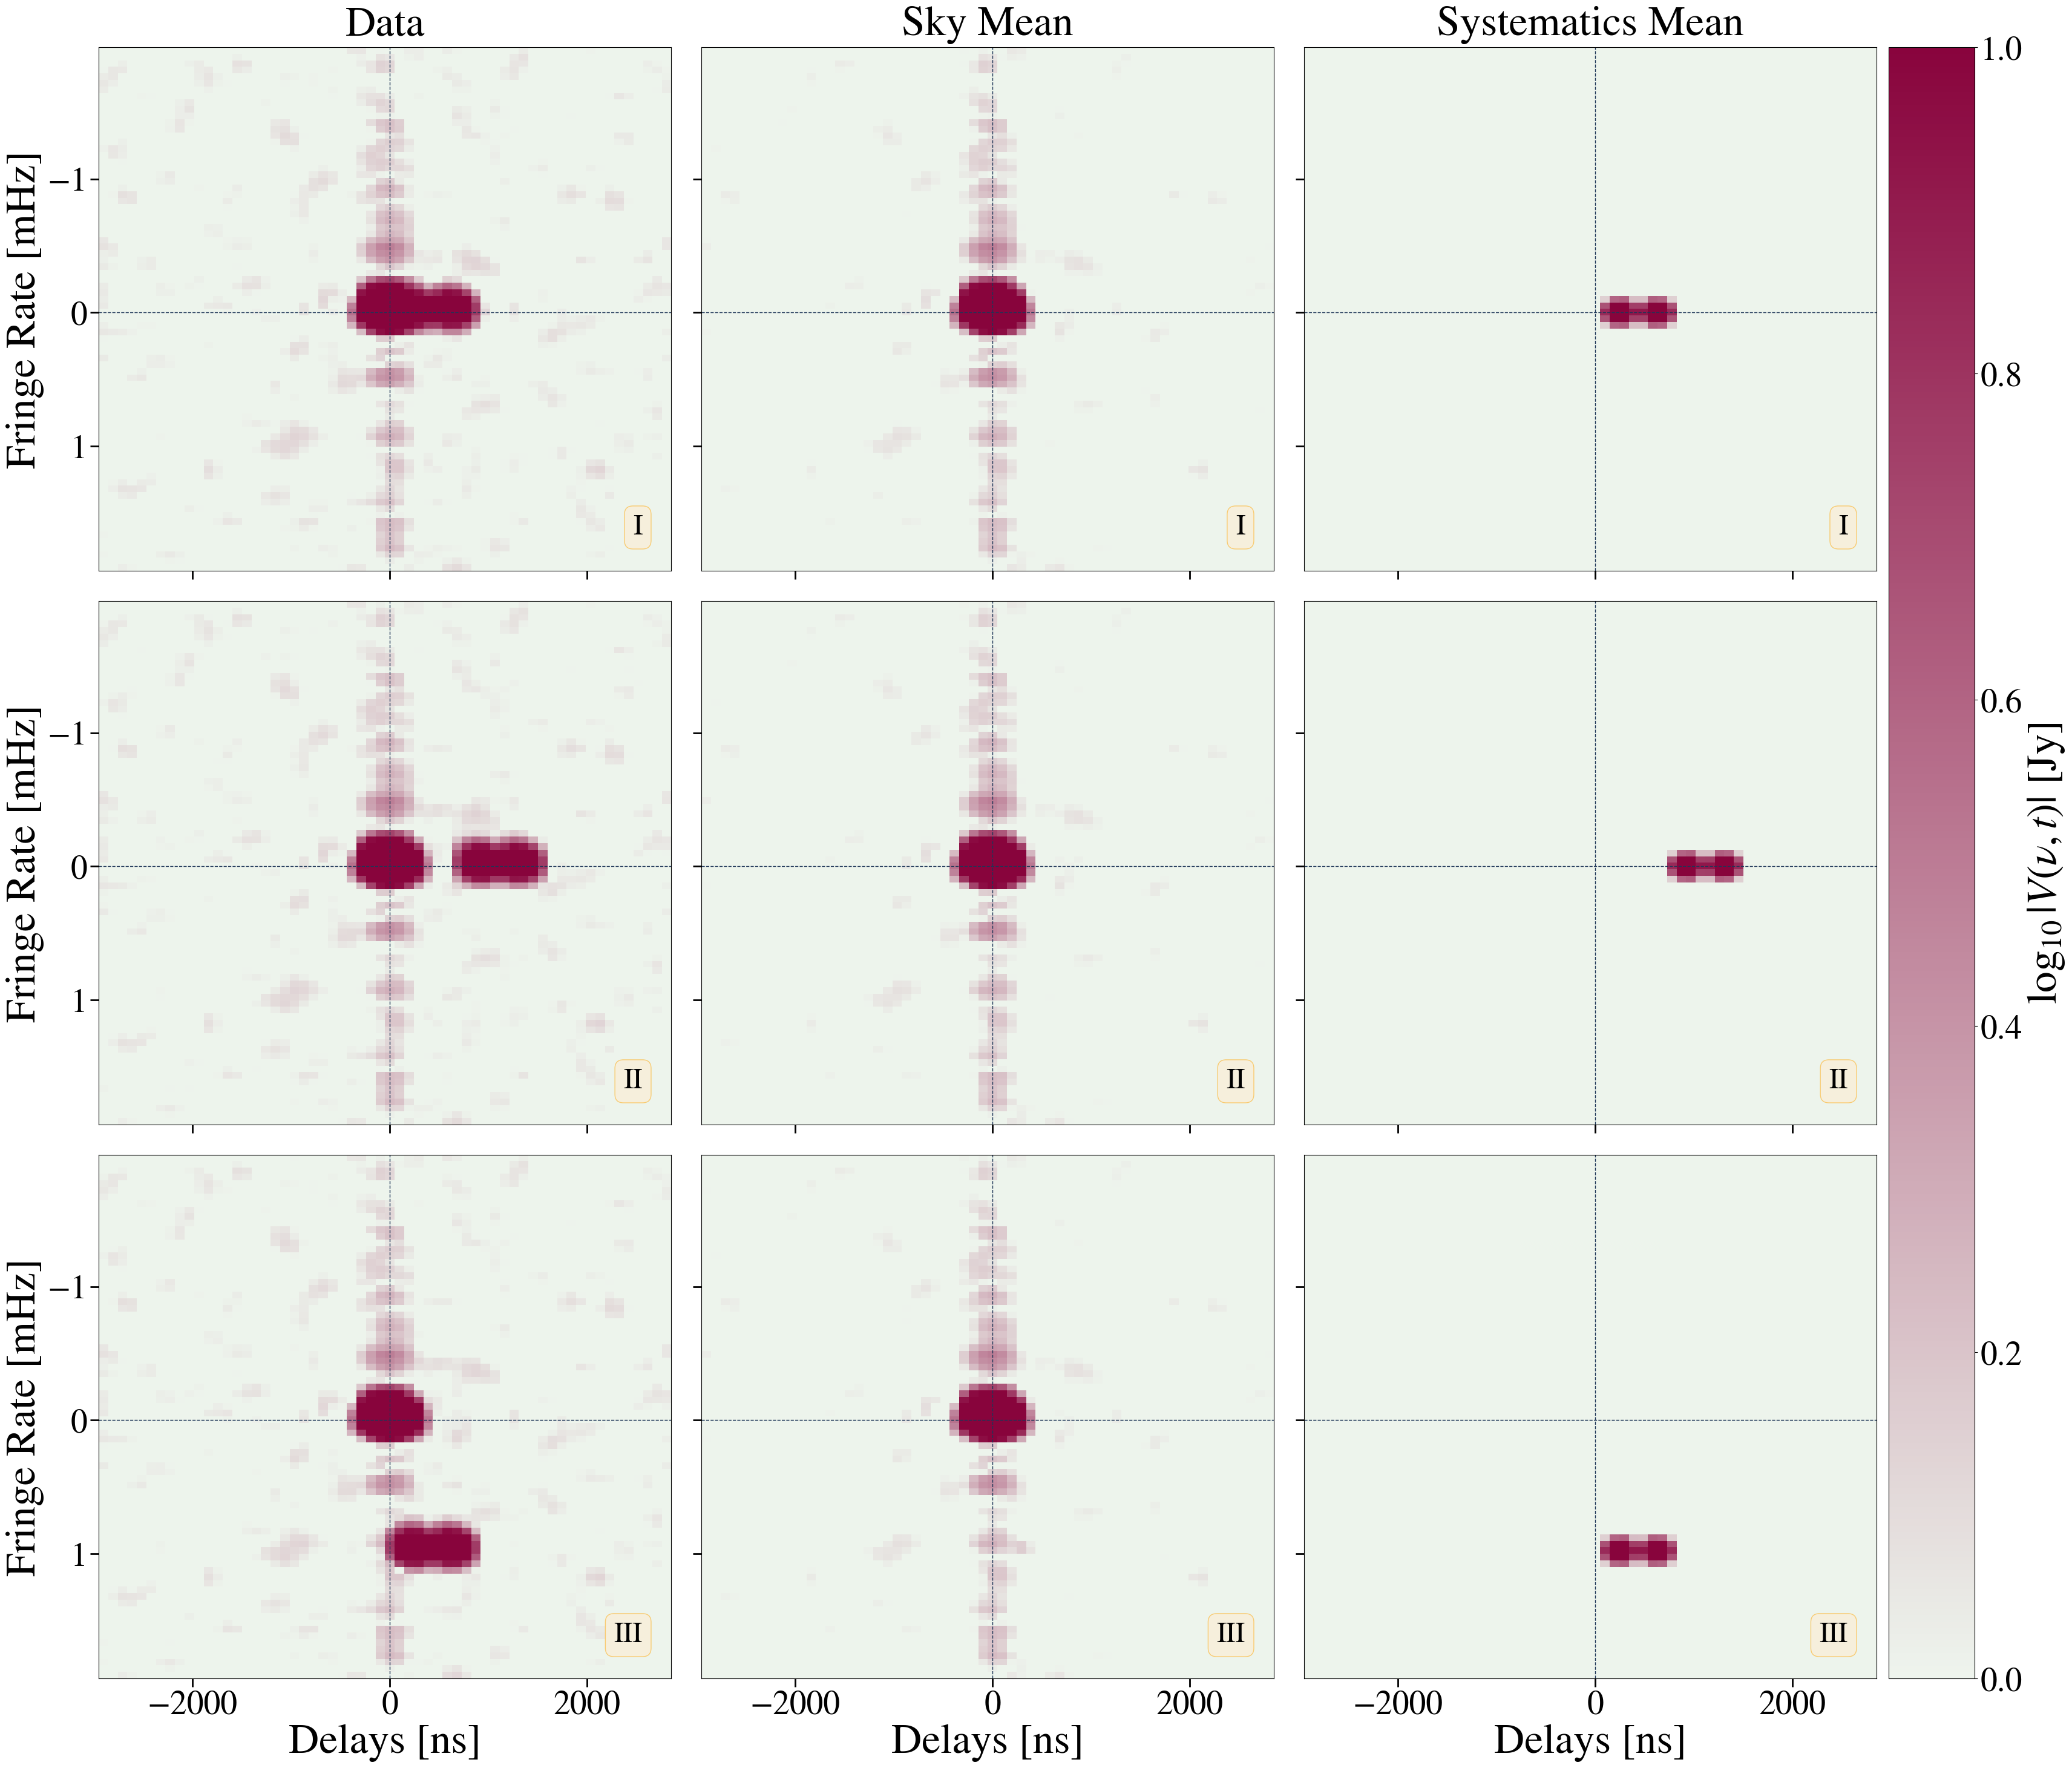

In [20]:
fig = plt.figure(figsize=(40, 35))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(3, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

c = 0
for a in range(3):
    im0 = plot_waterfalls_from_dlfr(
        data_true_dlfr_all[a], freqs * 1e6, lsts, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1
    im1 = plot_waterfalls_from_dlfr(
        mean_sky_dlfr_all[a], freqs * 1e6, lsts, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1
    im2 = plot_waterfalls_from_dlfr(
        delta_g_dlfr_mean_all[a], freqs * 1e6, lsts, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1

fig_labels_all = ['I'] * 3 + ['II'] * 3 + ['III'] * 3
fig_titles     = ['Data', 'Sky Mean', 'Systematics Mean']
for i, a in enumerate(ax):
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=40)
    a.set_xlabel('Delays [ns]', fontsize=50)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=50)
    a.text(0.95, 0.07, fig_labels_all[i], bbox=bbox, transform=a.transAxes, horizontalalignment='right')
for i, a in enumerate(ax[:3]):
    a.set_title(fig_titles[i], fontsize=50, pad=15)

for a in ax:
    a.axvline(0, color=colors[0], linestyle='--', linewidth=1)
    a.axhline(0, color=colors[0], linestyle='--', linewidth=1)
    
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(r'$\log_{10}|V(\nu, t)|$ [Jy]', size=50)
cbar.ax.tick_params(labelsize=40)
plt.savefig(fig_dir + '/data_vs_sky_2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5: Result waterfalls (single case)

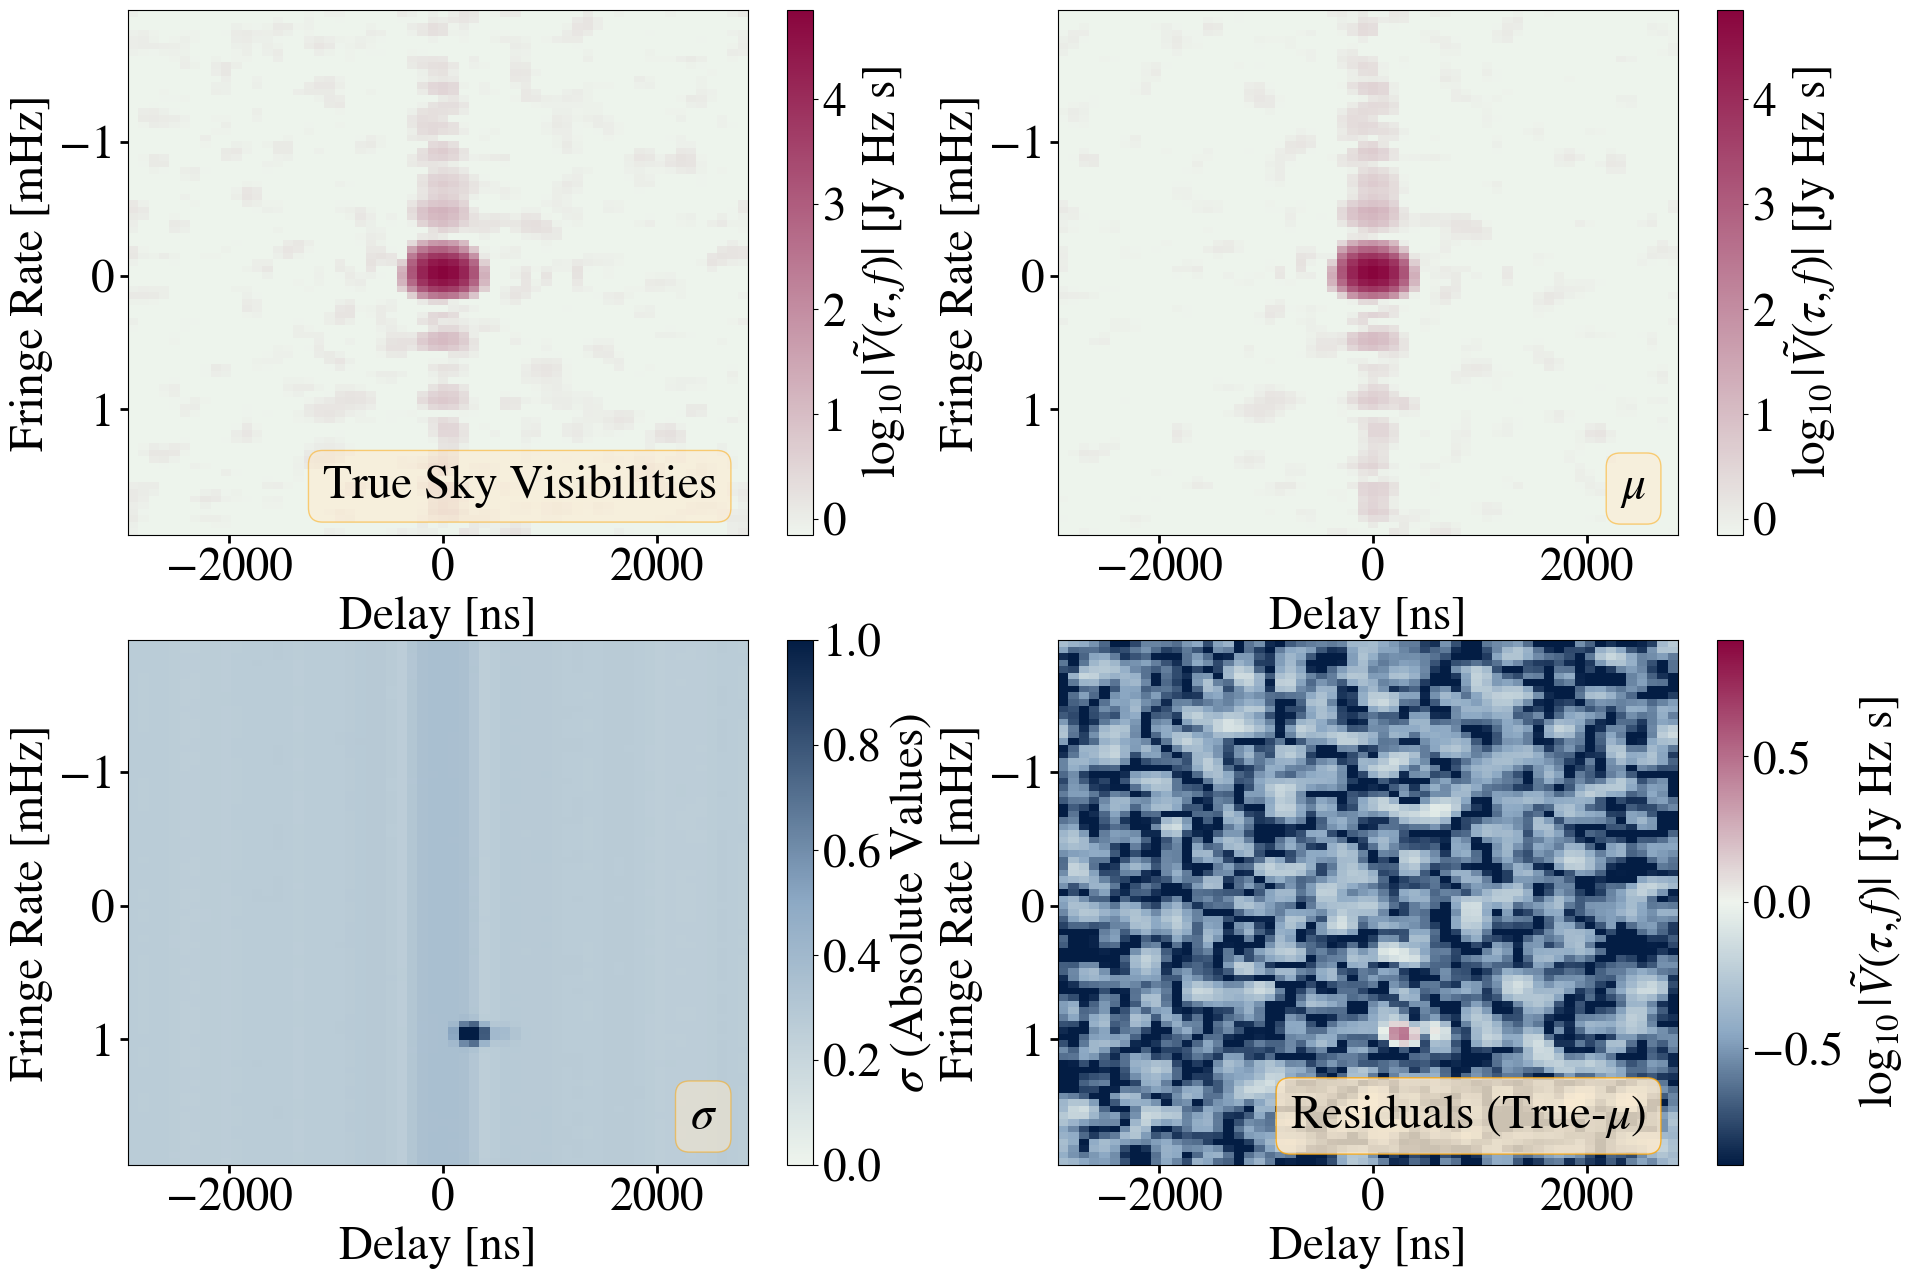

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Sky Visibilities', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    np.std(sky_dlfr_arr, axis=0), freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sky_true_dlfr - mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
plt.savefig(fig_dir + '/result_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figures 5 & 6 v2: All-cases result waterfalls

Versions of Figures 5 and 6 with all three cases shown simultaneously.
Columns = Case I / II / III; Rows = True / Mean / Std / Residuals.

In [14]:
# All-cases statistics for the v2 figures were computed in the "All-cases data" cell above.
# Lists are indexed 0/1/2 = Case I / II / III.
# Available: sky_true_dlfr_all, mean_sky_dlfr_all, std_sky_dlfr_all, res_sky_dlfr_all,
#            delta_g_dlfr_true_all, delta_g_dlfr_mean_all, delta_g_dlfr_std_all, res_sys_dlfr_all.

case_labels_v2 = ['Case I', 'Case II', 'Case III']
row_labels_v2  = ['True', r'$\mu$', r'$\sigma$', 'Residuals']

### Figure 5 v2: Sky result waterfalls (all cases)

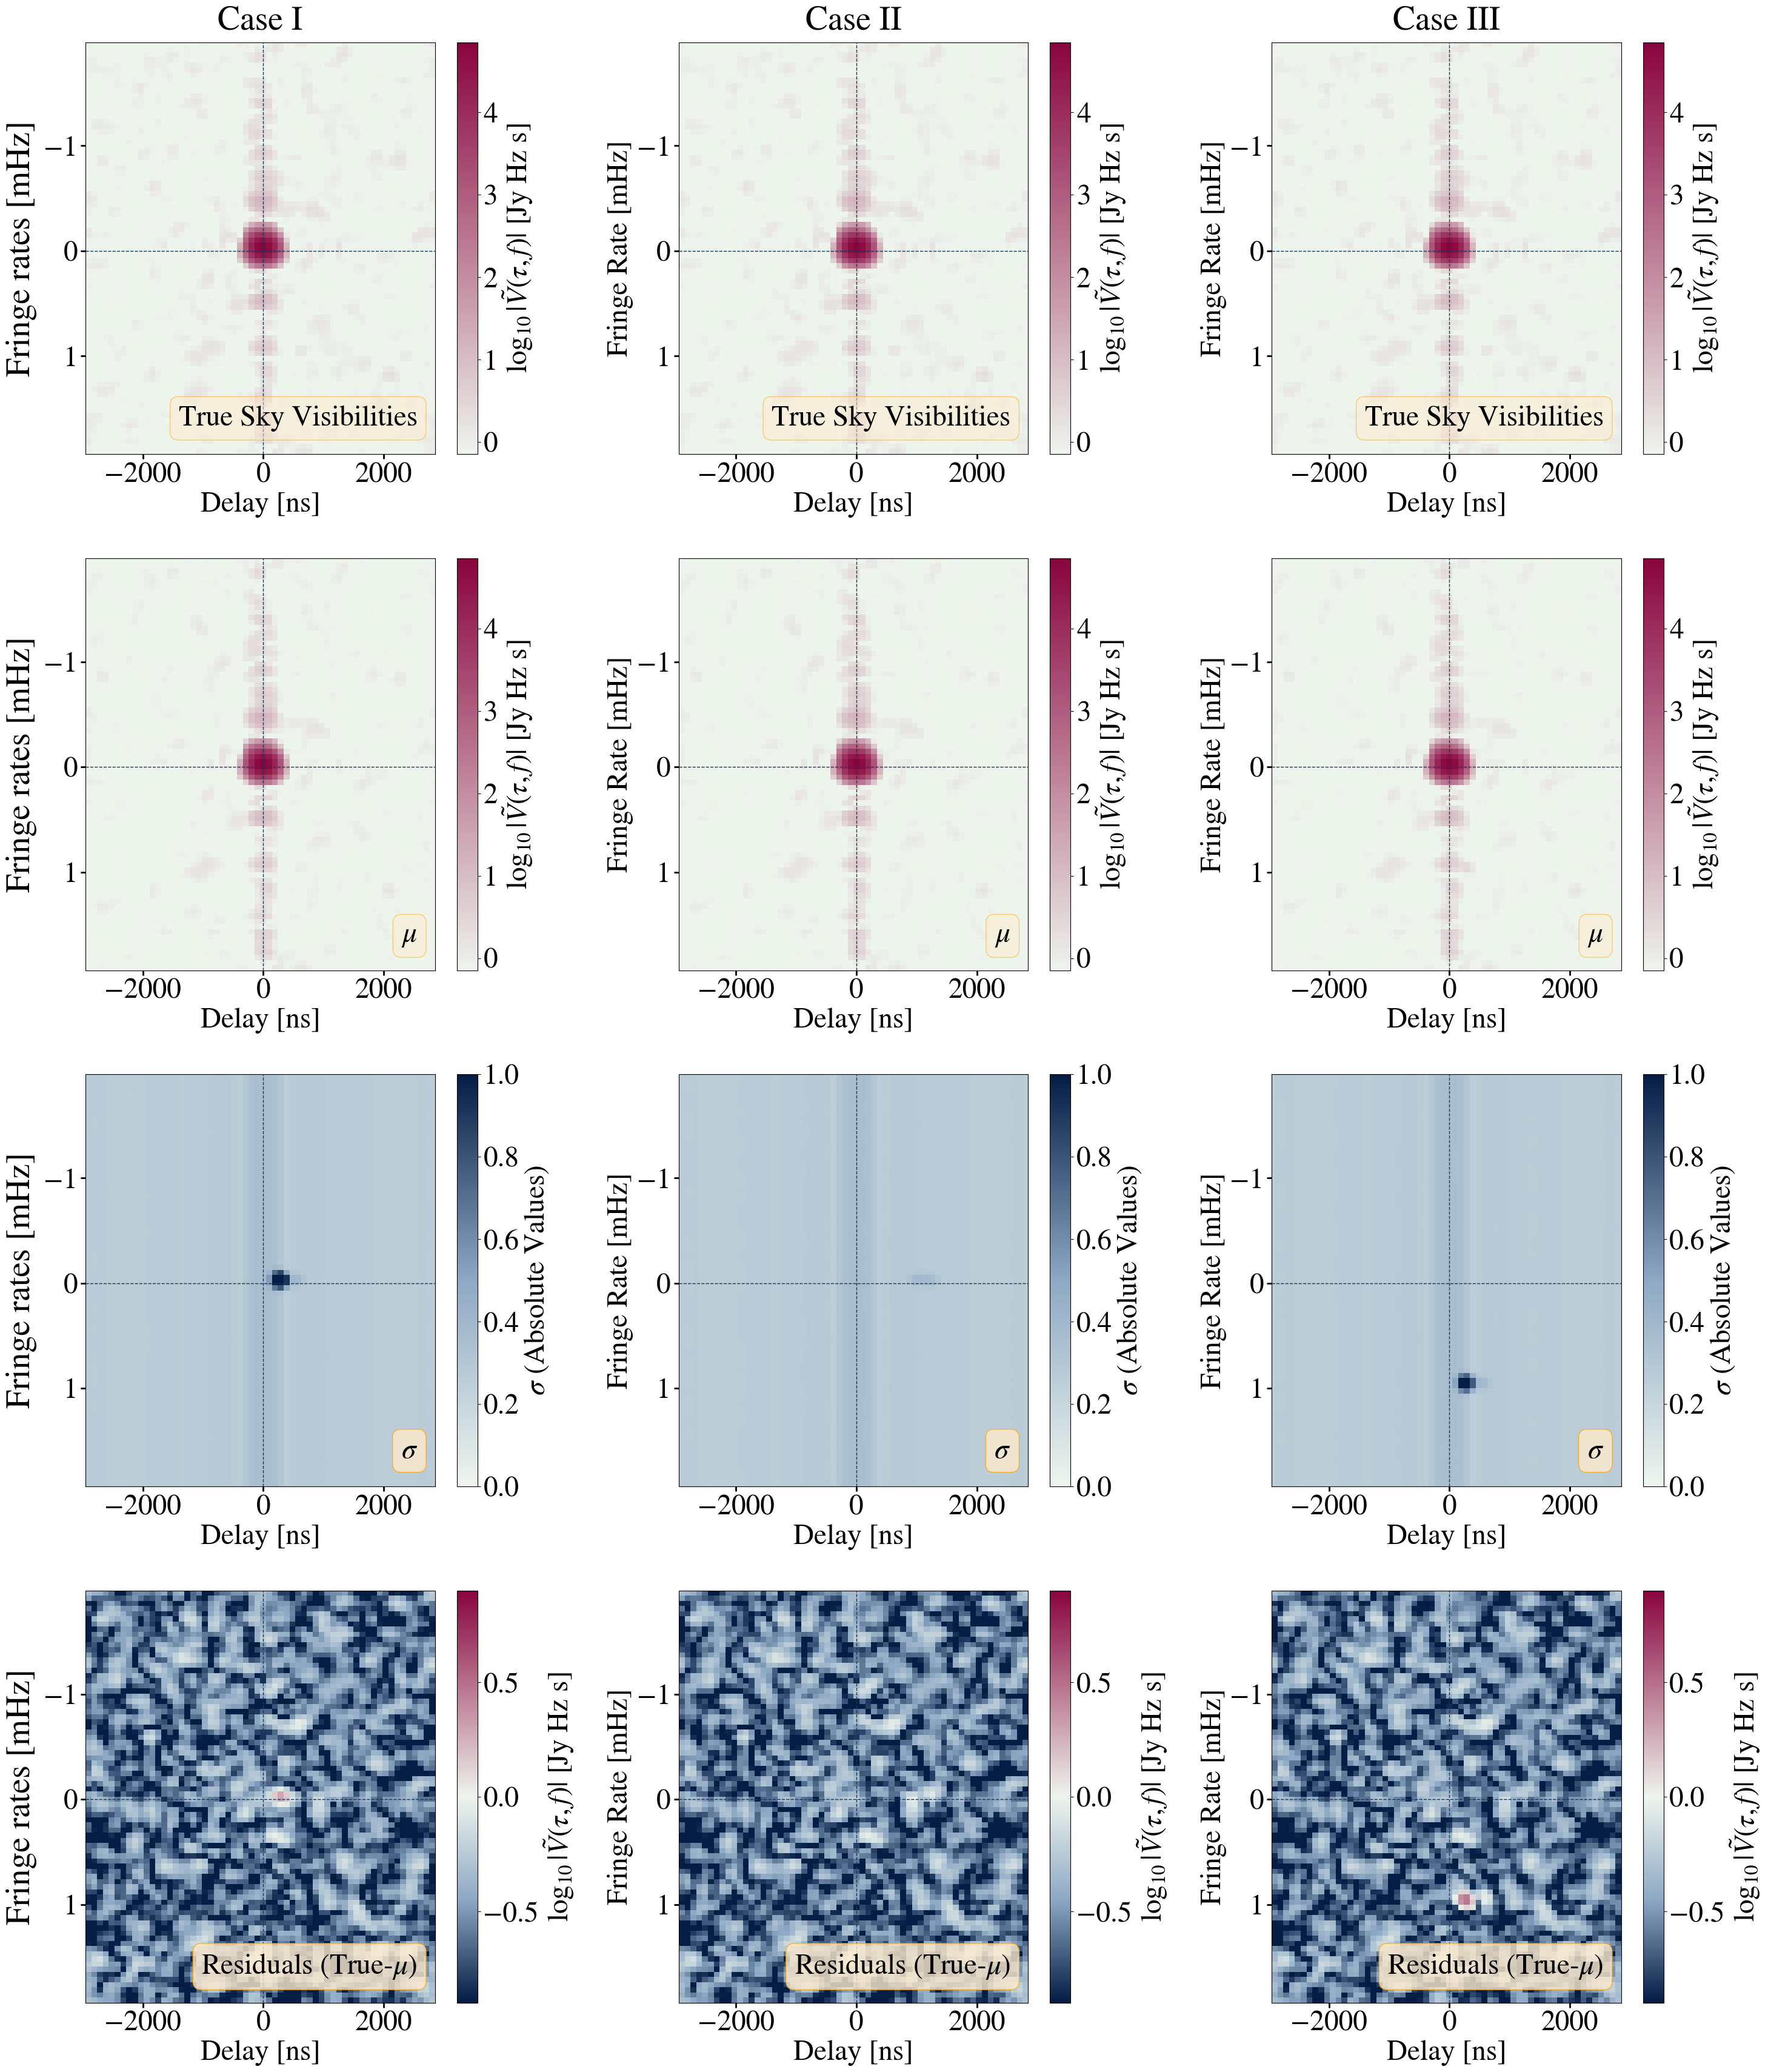

In [15]:
# Figure 5 v2: Sky result waterfalls – all cases
# Rows: True | Mean | Std | Residuals     Columns: Case I | Case II | Case III

case_labels_v2 = ['Case I', 'Case II', 'Case III']
row_labels_v2  = ['Fringe rates [mHz]', 
                  'Fringe rates [mHz]', 
                  'Fringe rates [mHz]', 
                  'Fringe rates [mHz]'
                  ]
annots_sky_v2  = [
    'True Sky Visibilities',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig5v2, axs5v2 = plt.subplots(4, 3, figsize=(30, 35))

for col in range(3):
    # Row 0: True
    plot_waterfalls_from_dlfr(
        sky_true_dlfr_all[col], freqs * 1e6, lsts,
        fig=fig5v2, ax=axs5v2[0, col], mode='log',
        vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
    )
    # Row 1: Mean
    plot_waterfalls_from_dlfr(
        mean_sky_dlfr_all[col], freqs * 1e6, lsts,
        fig=fig5v2, ax=axs5v2[1, col], mode='log',
        vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
    )
    # Row 2: Std
    plot_waterfalls_from_dlfr(
        std_sky_dlfr_all[col], freqs * 1e6, lsts,
        fig=fig5v2, ax=axs5v2[2, col], mode='abs',
        vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
        cbar_label=r'$\sigma$ (Absolute Values)',
    )
    # Row 3: Residuals
    plot_waterfalls_from_dlfr(
        res_sky_dlfr_all[col], freqs * 1e6, lsts,
        fig=fig5v2, ax=axs5v2[3, col], mode='log',
        vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
    )

# Column titles and row y-labels
for col, lbl in enumerate(case_labels_v2):
    axs5v2[0, col].set_title(lbl, fontsize=40, pad=15)
for row, lbl in enumerate(row_labels_v2):
    axs5v2[row, 0].set_ylabel(lbl, fontsize=40, labelpad=8)

# Per-panel annotations
for row in range(4):
    bbox_use = bbox_res if row >= 2 else bbox
    for col in range(3):
        axs5v2[row, col].text(
            0.95, 0.07, annots_sky_v2[row], bbox=bbox_use,
            transform=axs5v2[row, col].transAxes, horizontalalignment='right',
        )

for ax in axs5v2.flatten():
    ax.axvline(0, color=colors[0], linestyle='--', linewidth=1)
    ax.axhline(0, color=colors[0], linestyle='--', linewidth=1)
fig5v2.tight_layout()
plt.savefig(fig_dir + '/result_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)


---
# Figure 6: Systematics result waterfalls (single case)

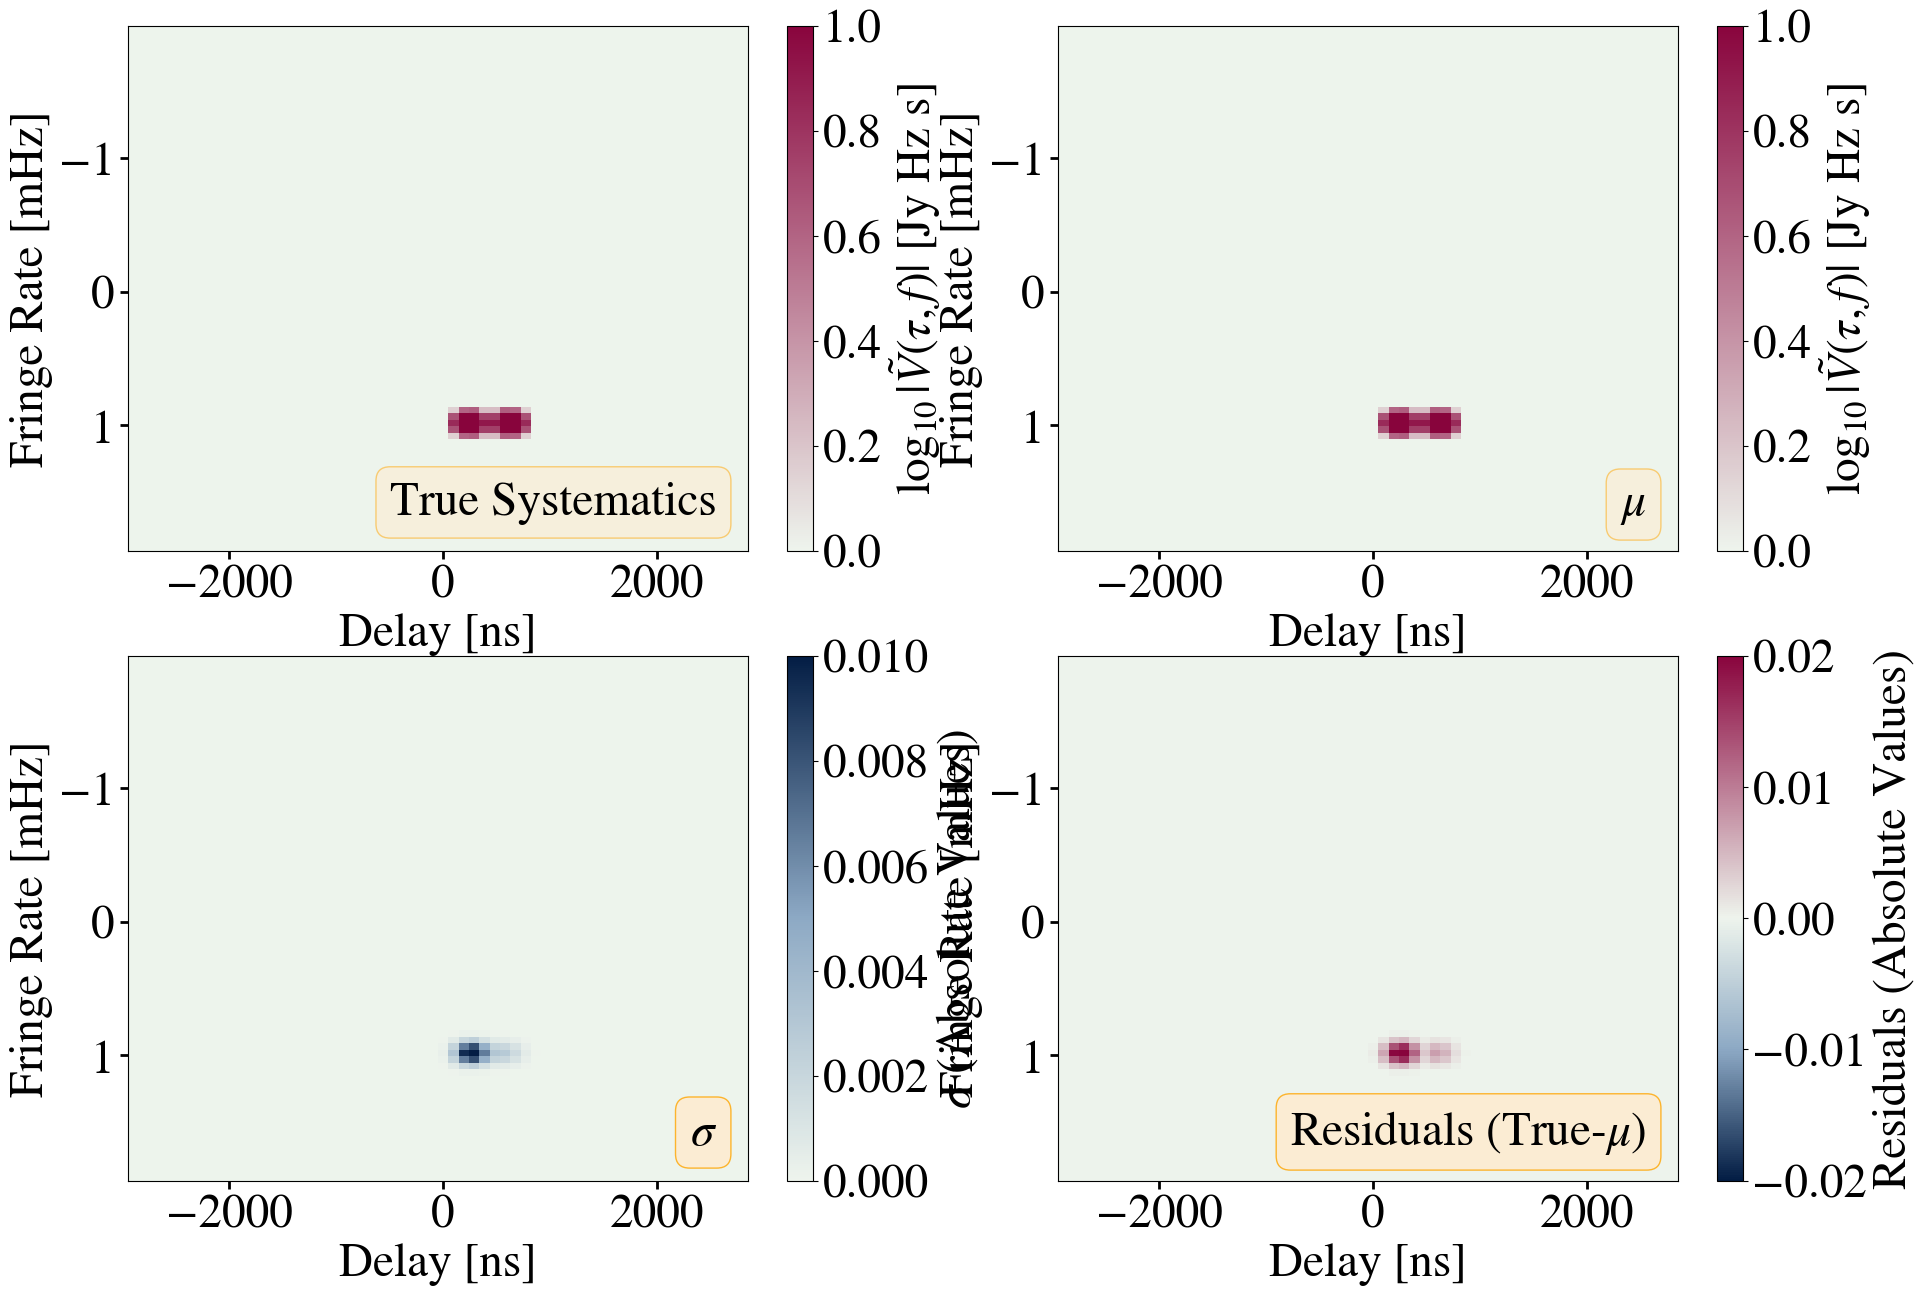

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    delta_g_dlfr_true, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Systematics', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_std, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sys_model_true_dlfr - sys_model_dlfr_mean, freqs * 1e6, lsts,
    fig=fig, ax=axs.flatten()[3], mode='abs', vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label='Residuals (Absolute Values)',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls.pdf', bbox_inches='tight', dpi=300)

### Figure 6 v2: Systematics result waterfalls (all cases)

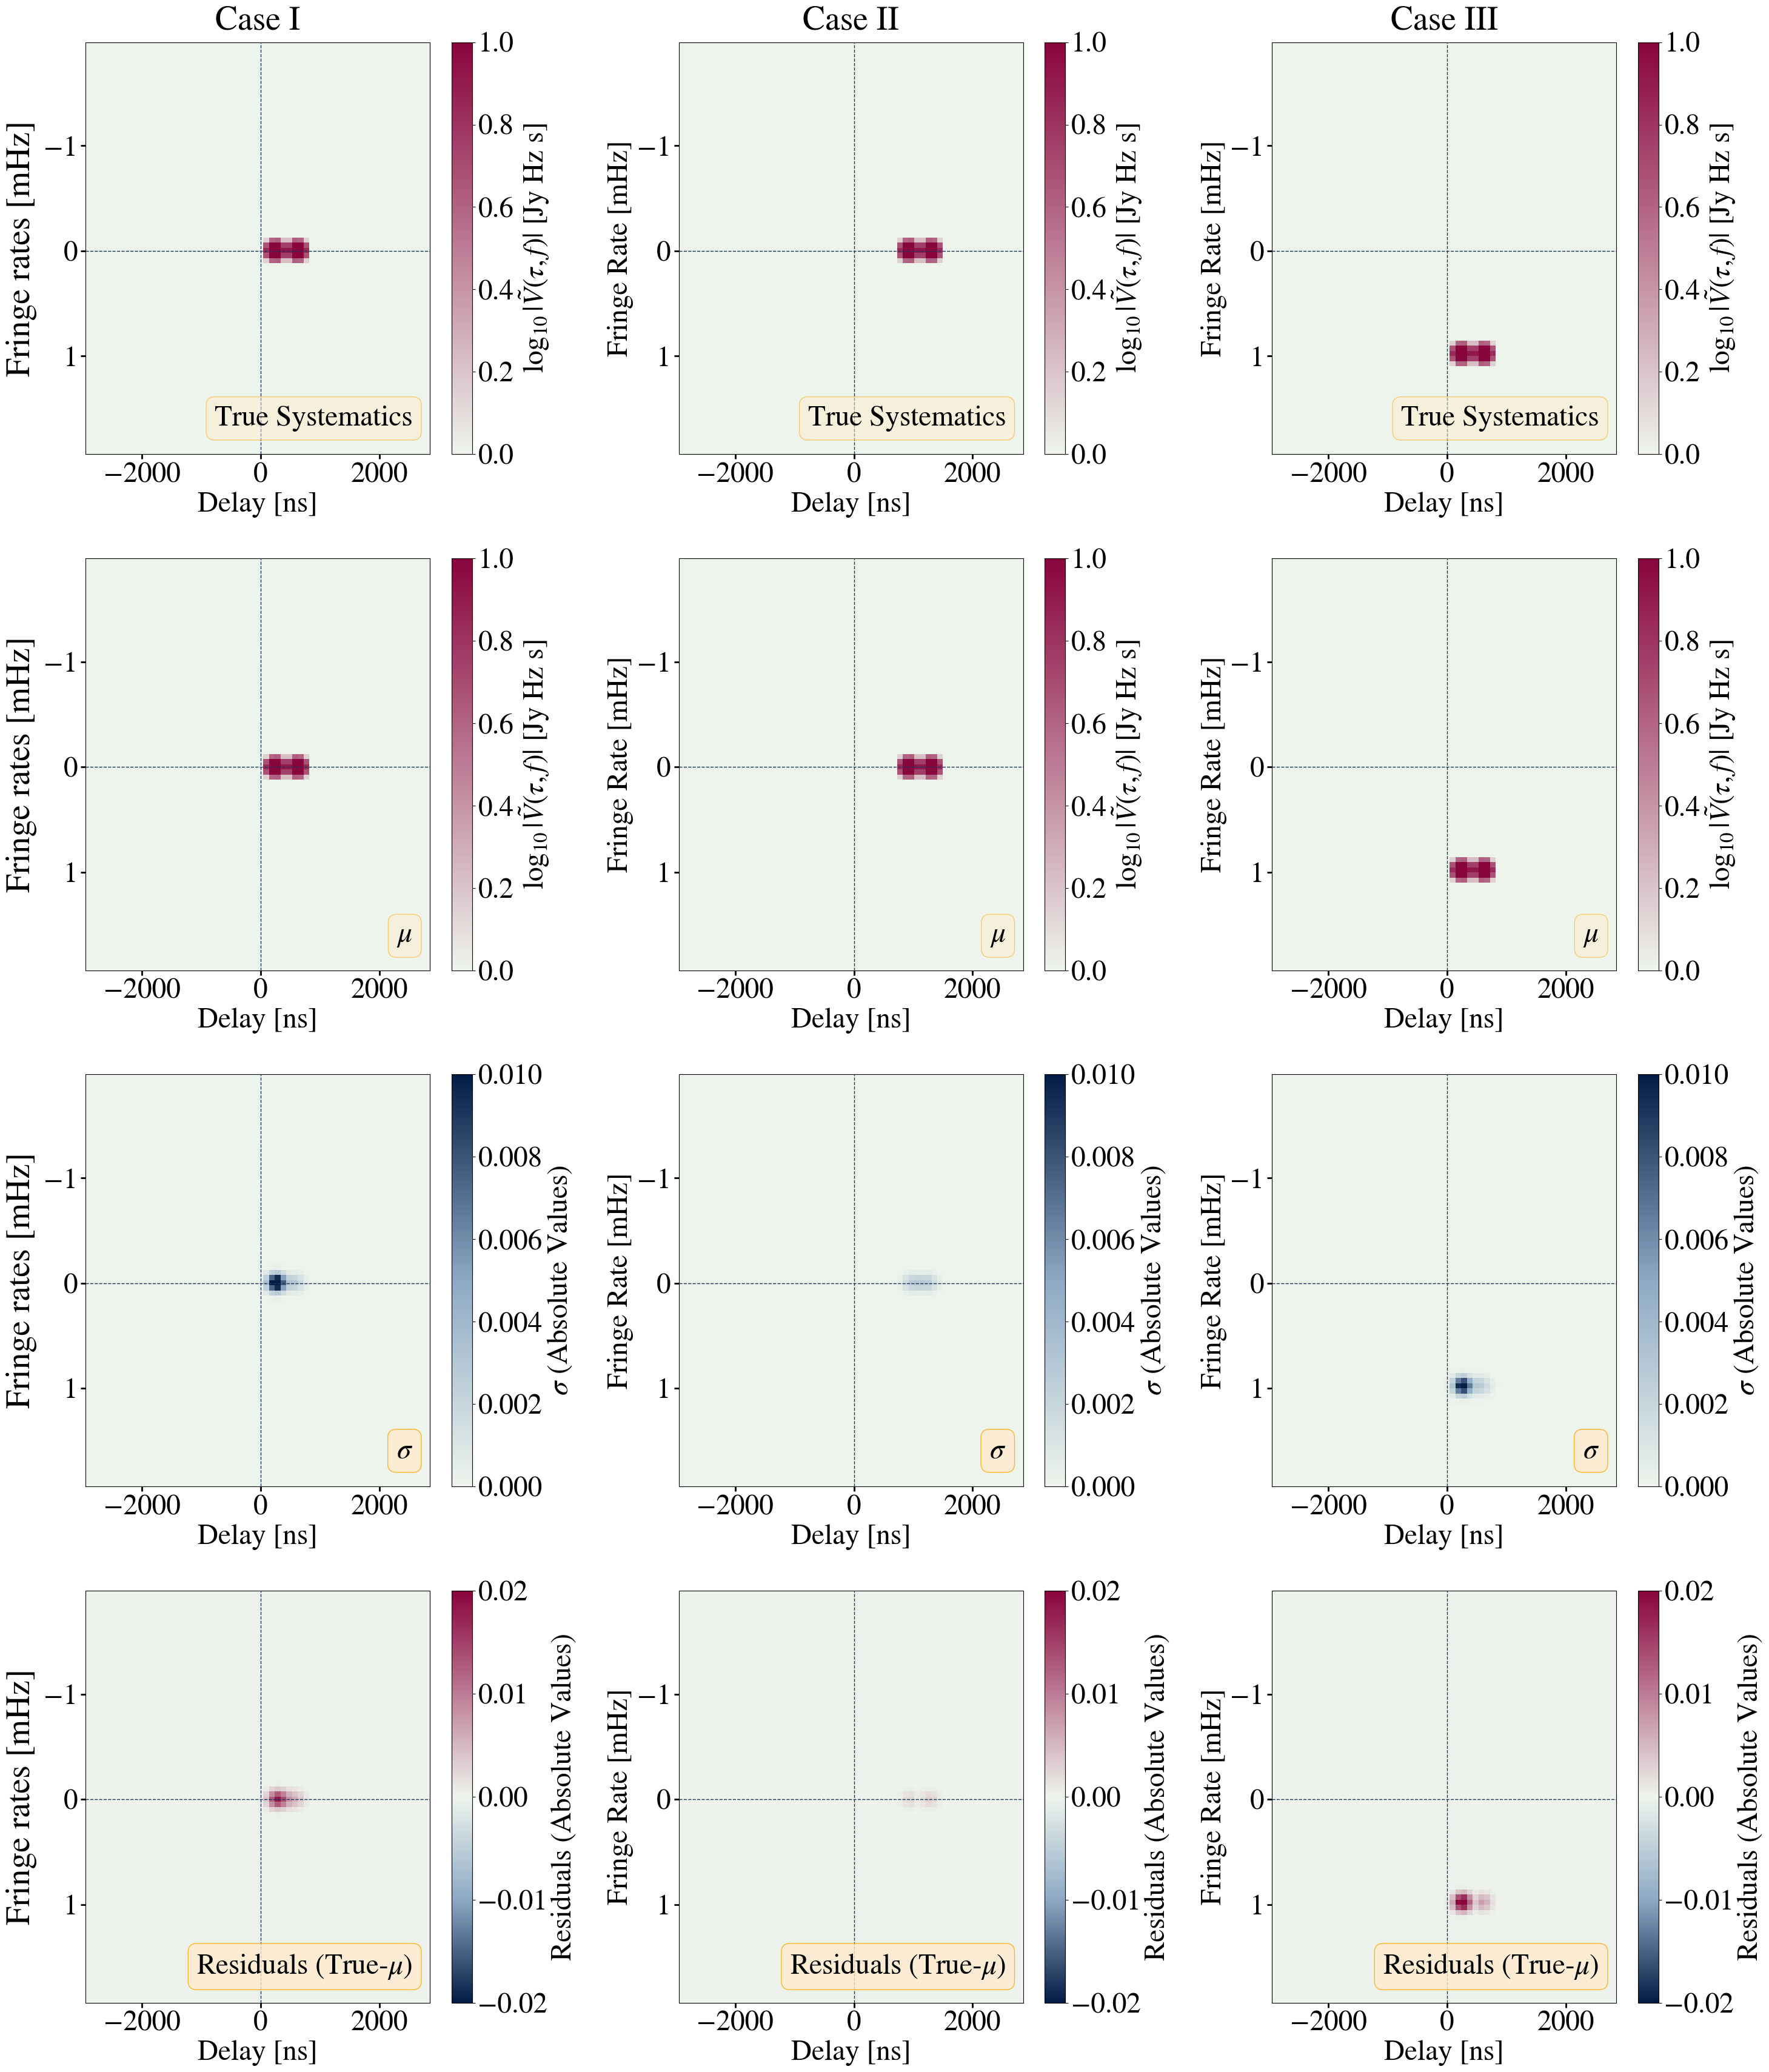

In [17]:
# Figure 6 v2: Systematics result waterfalls – all cases
# Rows: True | Mean | Std | Residuals     Columns: Case I | Case II | Case III

annots_sys_v2 = [
    'True Systematics',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig6v2, axs6v2 = plt.subplots(4, 3, figsize=(30, 35))

for col in range(3):
    # Row 0: True
    plot_waterfalls_from_dlfr(
        delta_g_dlfr_true_all[col], freqs * 1e6, lsts,
        fig=fig6v2, ax=axs6v2[0, col], mode='log',
        vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
    )
    # Row 1: Mean
    plot_waterfalls_from_dlfr(
        delta_g_dlfr_mean_all[col], freqs * 1e6, lsts,
        fig=fig6v2, ax=axs6v2[1, col], mode='log',
        vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
    )
    # Row 2: Std
    plot_waterfalls_from_dlfr(
        delta_g_dlfr_std_all[col], freqs * 1e6, lsts,
        fig=fig6v2, ax=axs6v2[2, col], mode='abs',
        vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None,
        limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
        cbar_label=r'$\sigma$ (Absolute Values)',
    )
    # Row 3: Residuals
    plot_waterfalls_from_dlfr(
        res_sys_dlfr_all[col], freqs * 1e6, lsts,
        fig=fig6v2, ax=axs6v2[3, col], mode='abs',
        vmin=-0.02, vmax=0.02, cmap=paper_map,
        dynamic_range=None, limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',
        cbar_label='Residuals (Absolute Values)',
    )

# Column titles and row y-labels
for col, lbl in enumerate(case_labels_v2):
    axs6v2[0, col].set_title(lbl, fontsize=40, pad=15)
for row, lbl in enumerate(row_labels_v2):
    axs6v2[row, 0].set_ylabel(lbl, fontsize=40, labelpad=8)

# Per-panel annotations
for row in range(4):
    bbox_use = bbox_res if row >= 2 else bbox
    for col in range(3):
        axs6v2[row, col].text(
            0.95, 0.07, annots_sys_v2[row], bbox=bbox_use,
            transform=axs6v2[row, col].transAxes, horizontalalignment='right',
        )

for ax in axs6v2.flatten():
    ax.axvline(0, color=colors[0], linestyle='--', linewidth=1)
    ax.axhline(0, color=colors[0], linestyle='--', linewidth=1)
fig6v2.tight_layout()
plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)


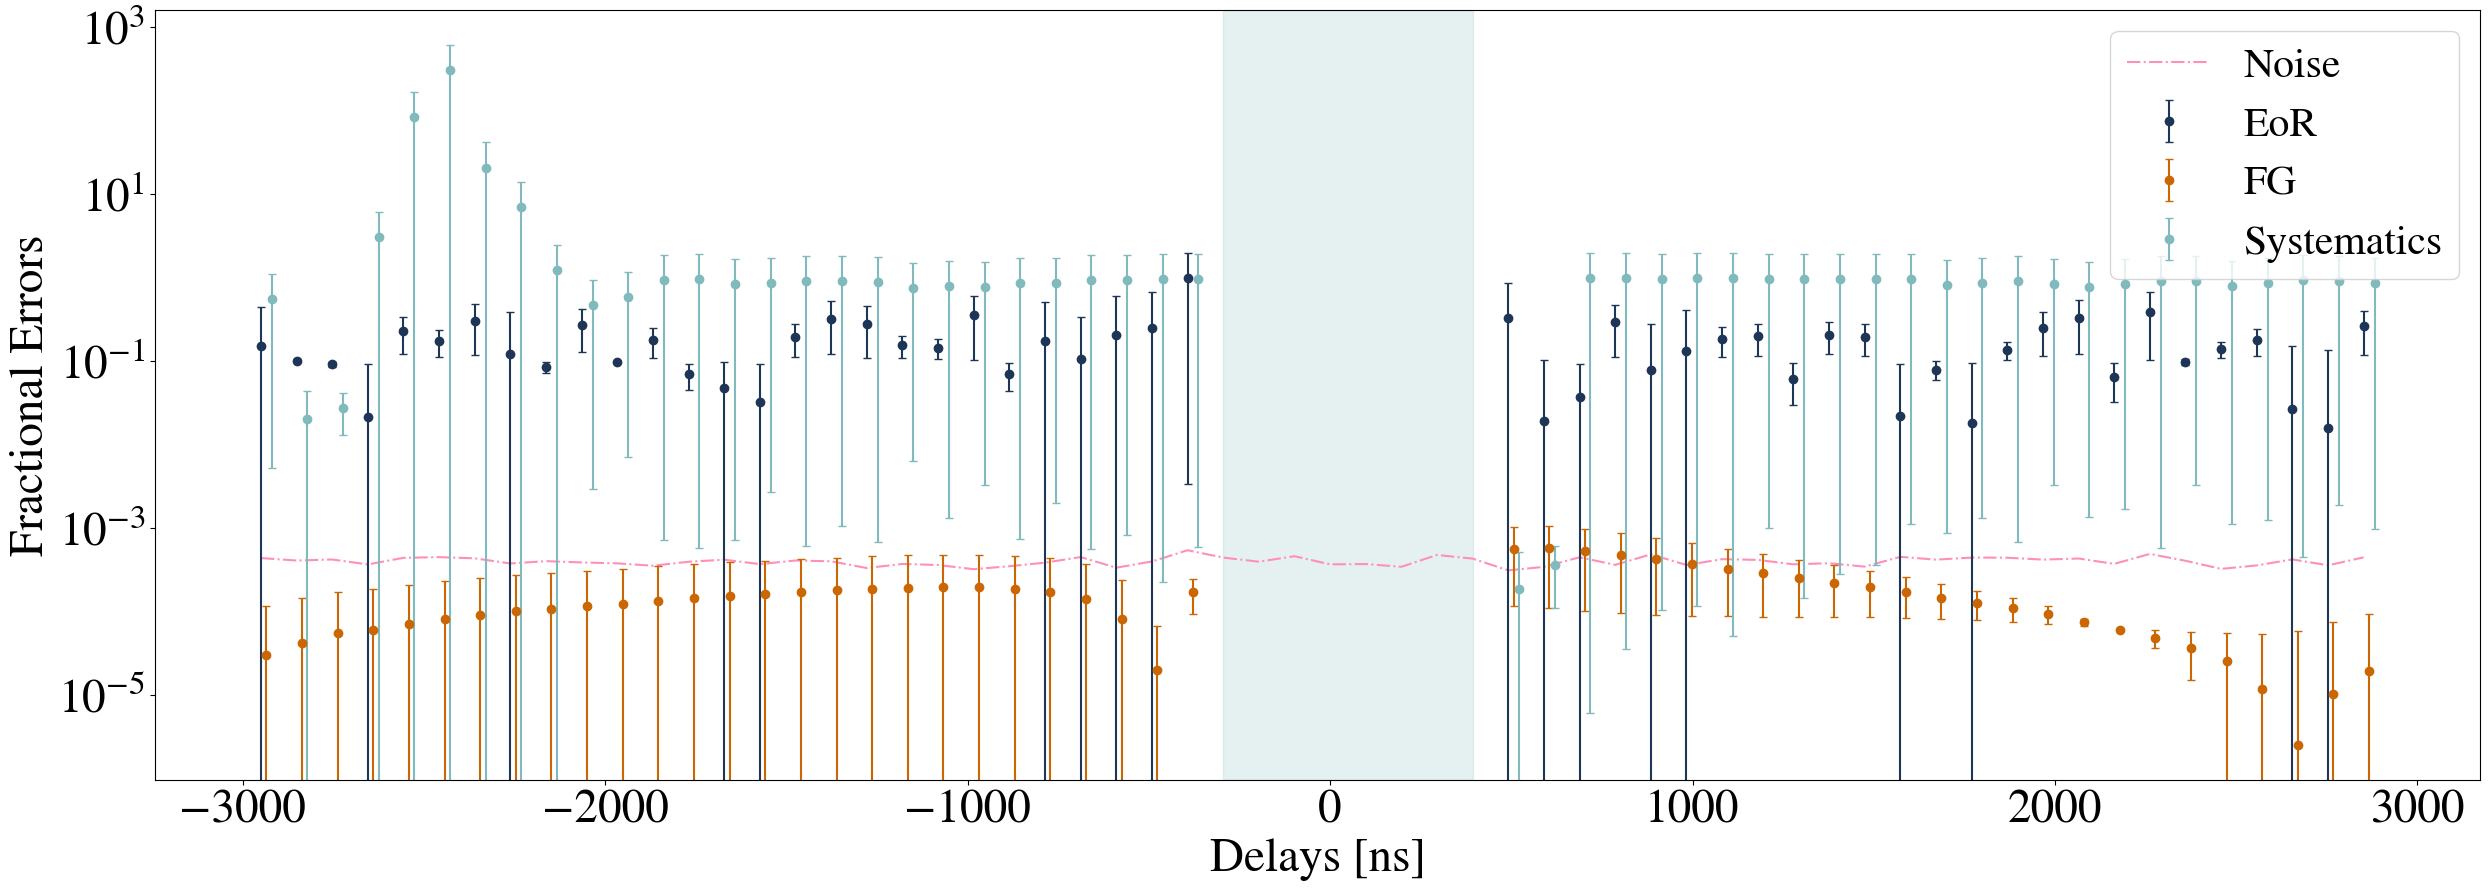

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(30, 10))

data_arr_errs = [
    (eor_pspec_true - ps_sample) / eor_pspec_true,
    (fg_pspec_true  - ps_fg)     / fg_pspec_true,
    (sys_pspec_true - ps_sys)    / sys_pspec_true,
]
plot_arr = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['EoR', 'FG', 'Systematics', 'Noise']

rm   = np.arange(27, 35)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = False

axs.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], label=fig_labels_err[-1])

for i in range(3):
    pa = plot_arr[i][keep]
    da = data_arr_errs[i][:, keep]
    std  = np.std(np.abs(da), axis=0)
    errs = np.vstack((pa - std, std - pa))
    axs.errorbar(
        delays[keep].value + (i * 15), np.abs(pa),
        yerr=np.abs(errs), fmt='o', color=colors[i], label=fig_labels_err[i], capsize=3,
    )
    axs.legend(fontsize=30)

axs.axvspan(delays[27].value, delays[34].value, facecolor=colors[i], ec=colors[i],alpha=0.2, zorder=0.1)
axs.set_yscale('log')
axs.set_xlabel('Delays [ns]')
axs.set_ylabel('Fractional Errors')
axs.yaxis.set_major_formatter(LogFormatterSciNotation())
plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)

## Figure 7 v2: Fractional errors by component – all cases

3 0
4 0
5 0
6 0


  1%|▏         | 1434/100000 [00:02<01:19, 1242.18it/s]

100%|██████████| 100000/100000 [00:49<00:00, 2006.45it/s]


10 0
11 0
12 0
13 0


100%|██████████| 100000/100000 [00:31<00:00, 3197.73it/s]


3 20
4 20
5 20
6 20


100%|██████████| 100000/100000 [00:44<00:00, 2263.27it/s]


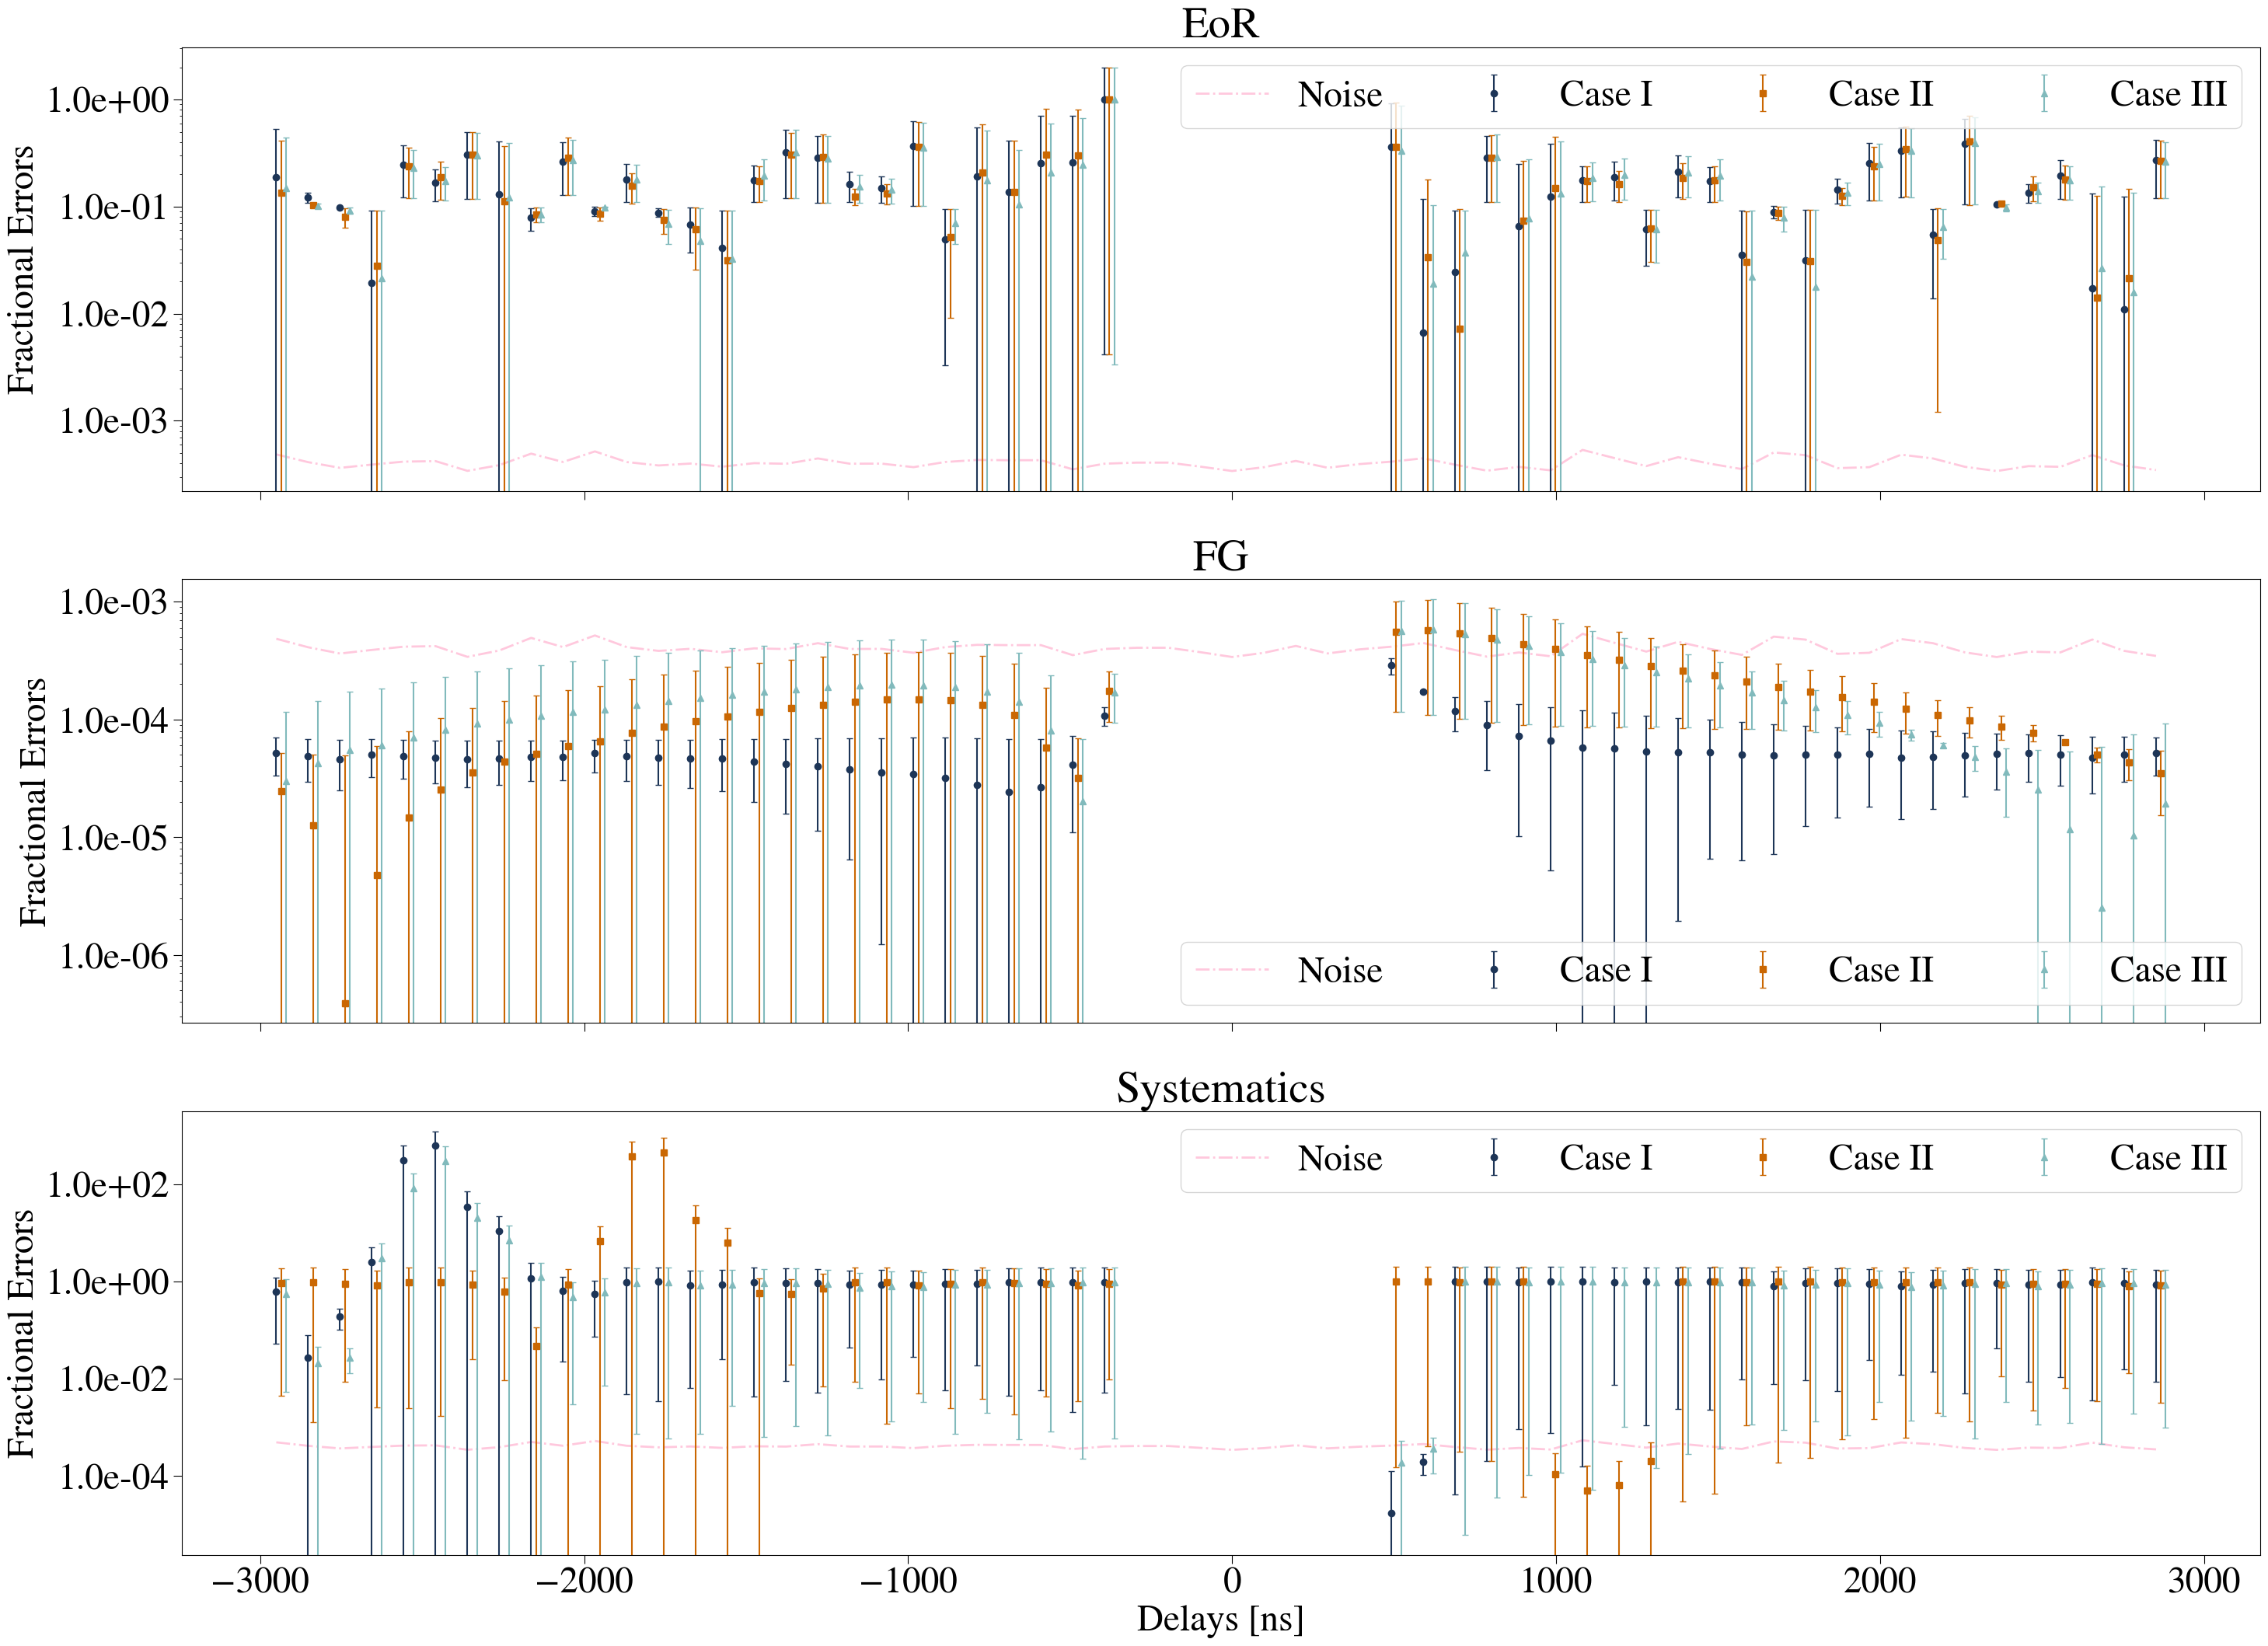

In [ ]:
# Rows: EoR  |  Foregrounds  |  Systematics
# Each row shows all three cases on the same axes.

component_labels = ['EoR', 'FG', 'Systematics']
case_labels_err  = ['Case I', 'Case II', 'Case III']
markers          = ['o', 's', '^']

rm   = np.arange(27, 35)
keep = np.ones(Nfreqs, dtype=bool)
keep[rm] = False

# ── Load per-case DPS data ────────────────────────────────────────────────────
ps_sample_all      = []
ps_fg_all          = []
ps_sys_all         = []
eor_pspec_true_all = []
fg_pspec_true_all  = []
sys_pspec_true_all = []

for case_i, run_ver in enumerate(run_version_arr):
    op_i             = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts * 24. / (2. * np.pi) * 3600., modes=nm_list_arr[case_i])
    fg_true_i        = np.load(result_dir + run_ver + '/fg_true.npy')
    fgmodes_i        = np.load(result_dir + run_ver + '/fgmodes.npy')
    fg_amps_i        = np.load(result_dir + run_ver + '/fg-amps.npy')
    eor_true_i       = np.load(result_dir + run_ver + '/eor_true.npy')
    b_sys_i          = np.load(result_dir + run_ver + '/b-sys.npy')
    sys_model_true_i = np.load(result_dir + run_ver + '/gain_true.npy')
    ps_sample_i      = np.load(result_dir + run_ver + '/dps-eor.npy')

    ps_fg_i  = np.empty(ps_sample_i.shape)
    ps_sys_i = np.empty(ps_sample_i.shape)
    for j in tqdm(range(Niter)):
        sys_model_j = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        ps_fg_i[j]  = calc_ps((fgmodes_i[:, :Nfgmodes] @ fg_amps_i[j].T).T)
        ps_sys_i[j] = calc_ps(1 + sys_model_j)

    ps_sample_all.append(ps_sample_i)
    ps_fg_all.append(ps_fg_i)
    ps_sys_all.append(ps_sys_i)
    eor_pspec_true_all.append(calc_ps(eor_true_i[:Ntimes, :Nfreqs]))
    fg_pspec_true_all.append(calc_ps(fg_true_i[:Ntimes, :Nfreqs]))
    sys_pspec_true_all.append(calc_ps(sys_model_true_i))

# ── Plot ──────────────────────────────────────────────────────────────────────
ps_all_by_comp = [ps_sample_all, ps_fg_all, ps_sys_all]
ps_true_by_comp = [eor_pspec_true_all, fg_pspec_true_all, sys_pspec_true_all]

fig7v2, axs7v2 = plt.subplots(3, 1, figsize=(30, 22), sharex=True)

for row, comp in enumerate(component_labels):
    ax = axs7v2[row]
    ax.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], lw=2, label='Noise')

    for case_i in range(3):
        pspec_true_c = ps_true_by_comp[row][case_i]
        ps_samples_c = ps_all_by_comp[row][case_i]
        errs_c = (pspec_true_c - ps_samples_c) / pspec_true_c
        pa     = errs_c.mean(axis=0)[keep]
        std    = np.std(np.abs(errs_c), axis=0)[keep]
        errs   = np.vstack((pa - std, std - pa))
        ax.errorbar(
            delays[keep].value + (case_i * 15), np.abs(pa), yerr=np.abs(errs),
            fmt=markers[case_i], color=colors[case_i], label=case_labels_err[case_i],
            capsize=3, elinewidth=1.5,
        )

    ax.set_yscale('log')
    ax.set_ylabel('Fractional Errors')
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
    ax.set_title(comp)
    ax.legend(ncol=4)
    ax.tick_params(length=8)

axs7v2[-1].set_xlabel('Delays [ns]')
fig7v2.tight_layout()
# plt.savefig(fig_dir + '/errors_components_v2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 8: Corner plot of b_sys (single case)

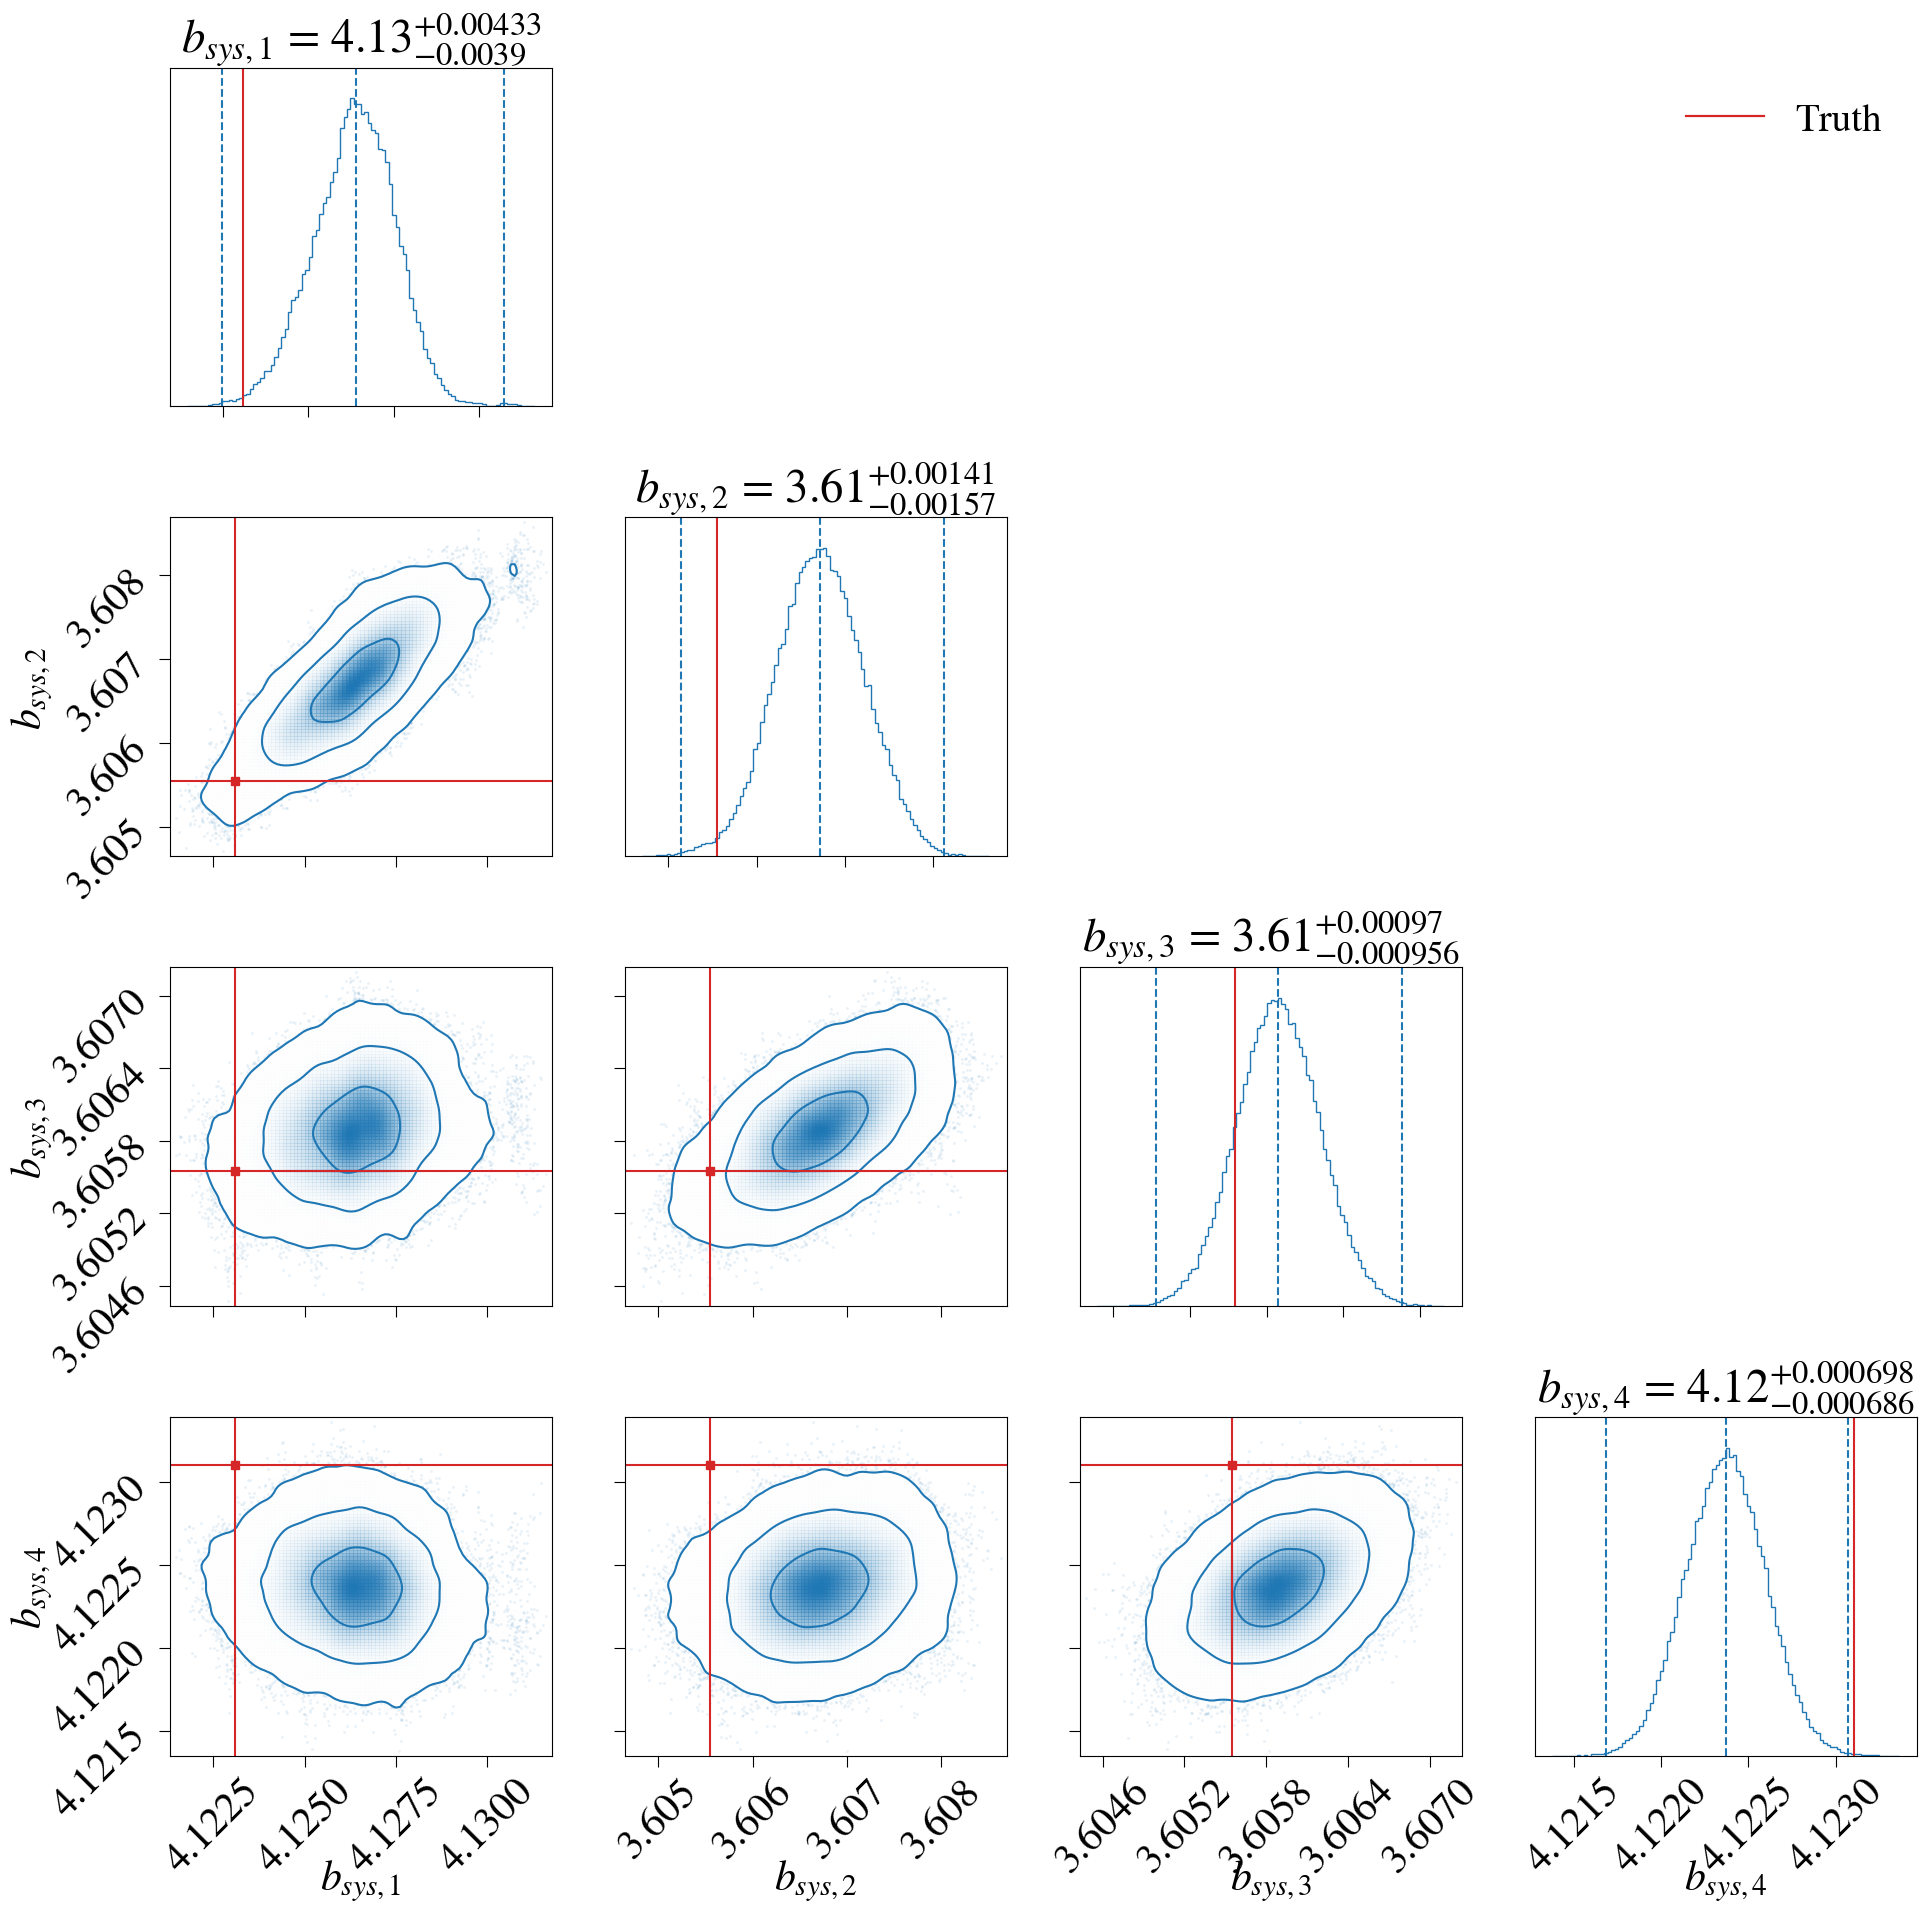

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
plt.rcParams['font.size']=28

for a in ax.flatten():
    a.tick_params(length=8)
corner_plot(
    np.abs(b_sys_gcr),
    truths=np.abs(sys_amps_true),
    labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'],
    fig=fig,
    nsigma=3,
)
plt.savefig(fig_dir + '/bsys_corner_plot.pdf', bbox_inches='tight', dpi=300)

---
# Figure 9: Systematics fractional error (single case)

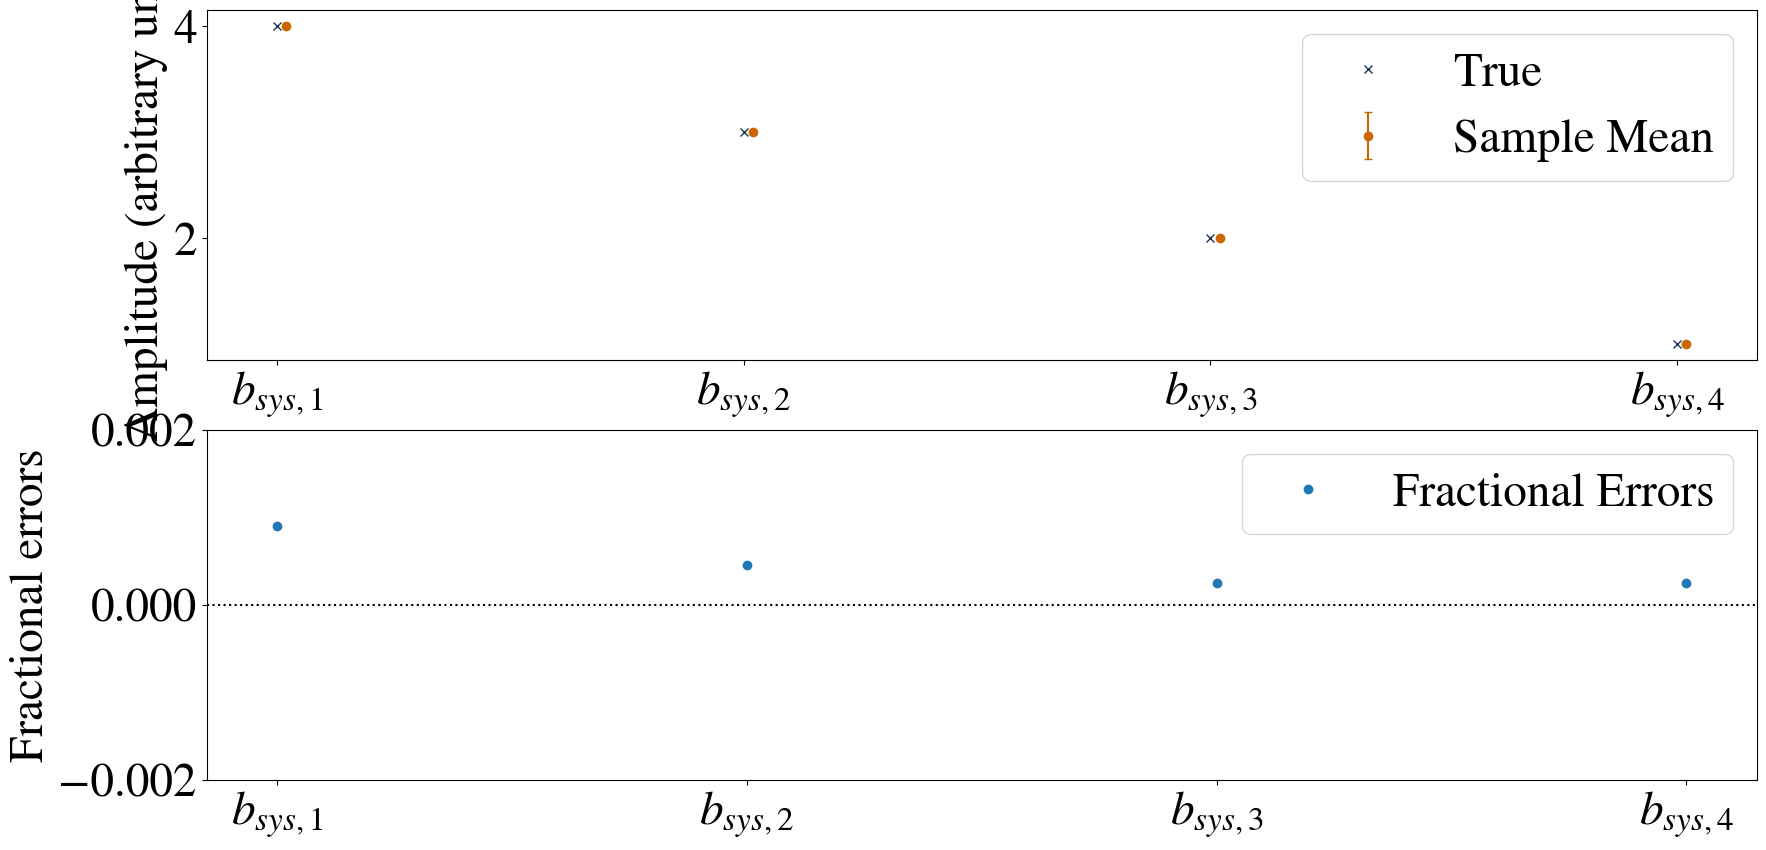

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

errs = np.vstack((
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
))

ax[0].plot(np.imag(sys_amps_true), 'x', c=colors[0], label='True')
ax[0].errorbar(
    [0.02, 1.02, 2.02, 3.02], np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o', yerr=errs, label='Sample Mean', capsize=3, c=colors[1],
)
ax[0].set_ylabel('Amplitude (arbitrary units)')
ax[0].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[0].legend()

res_mean = np.abs(sys_amps_true - b_sys_gcr.mean(axis=0)) / np.abs(sys_amps_true)
ax[1].plot([0, 1, 2, 3], res_mean, 'o', label='Fractional Errors')
ax[1].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[1].axhline(0, c='k', ls='dotted')
ax[1].set_ylabel('Fractional errors')
ax[1].set_ylim(-0.002, 0.002)
ax[1].legend()
plt.savefig(fig_dir + '/sys_frac_error.pdf', bbox_inches='tight', dpi=300)

---
# Figure 10: Delay power spectra (all cases)

-0.22818489548694623
-0.22282483862974284
-0.23004725761960312


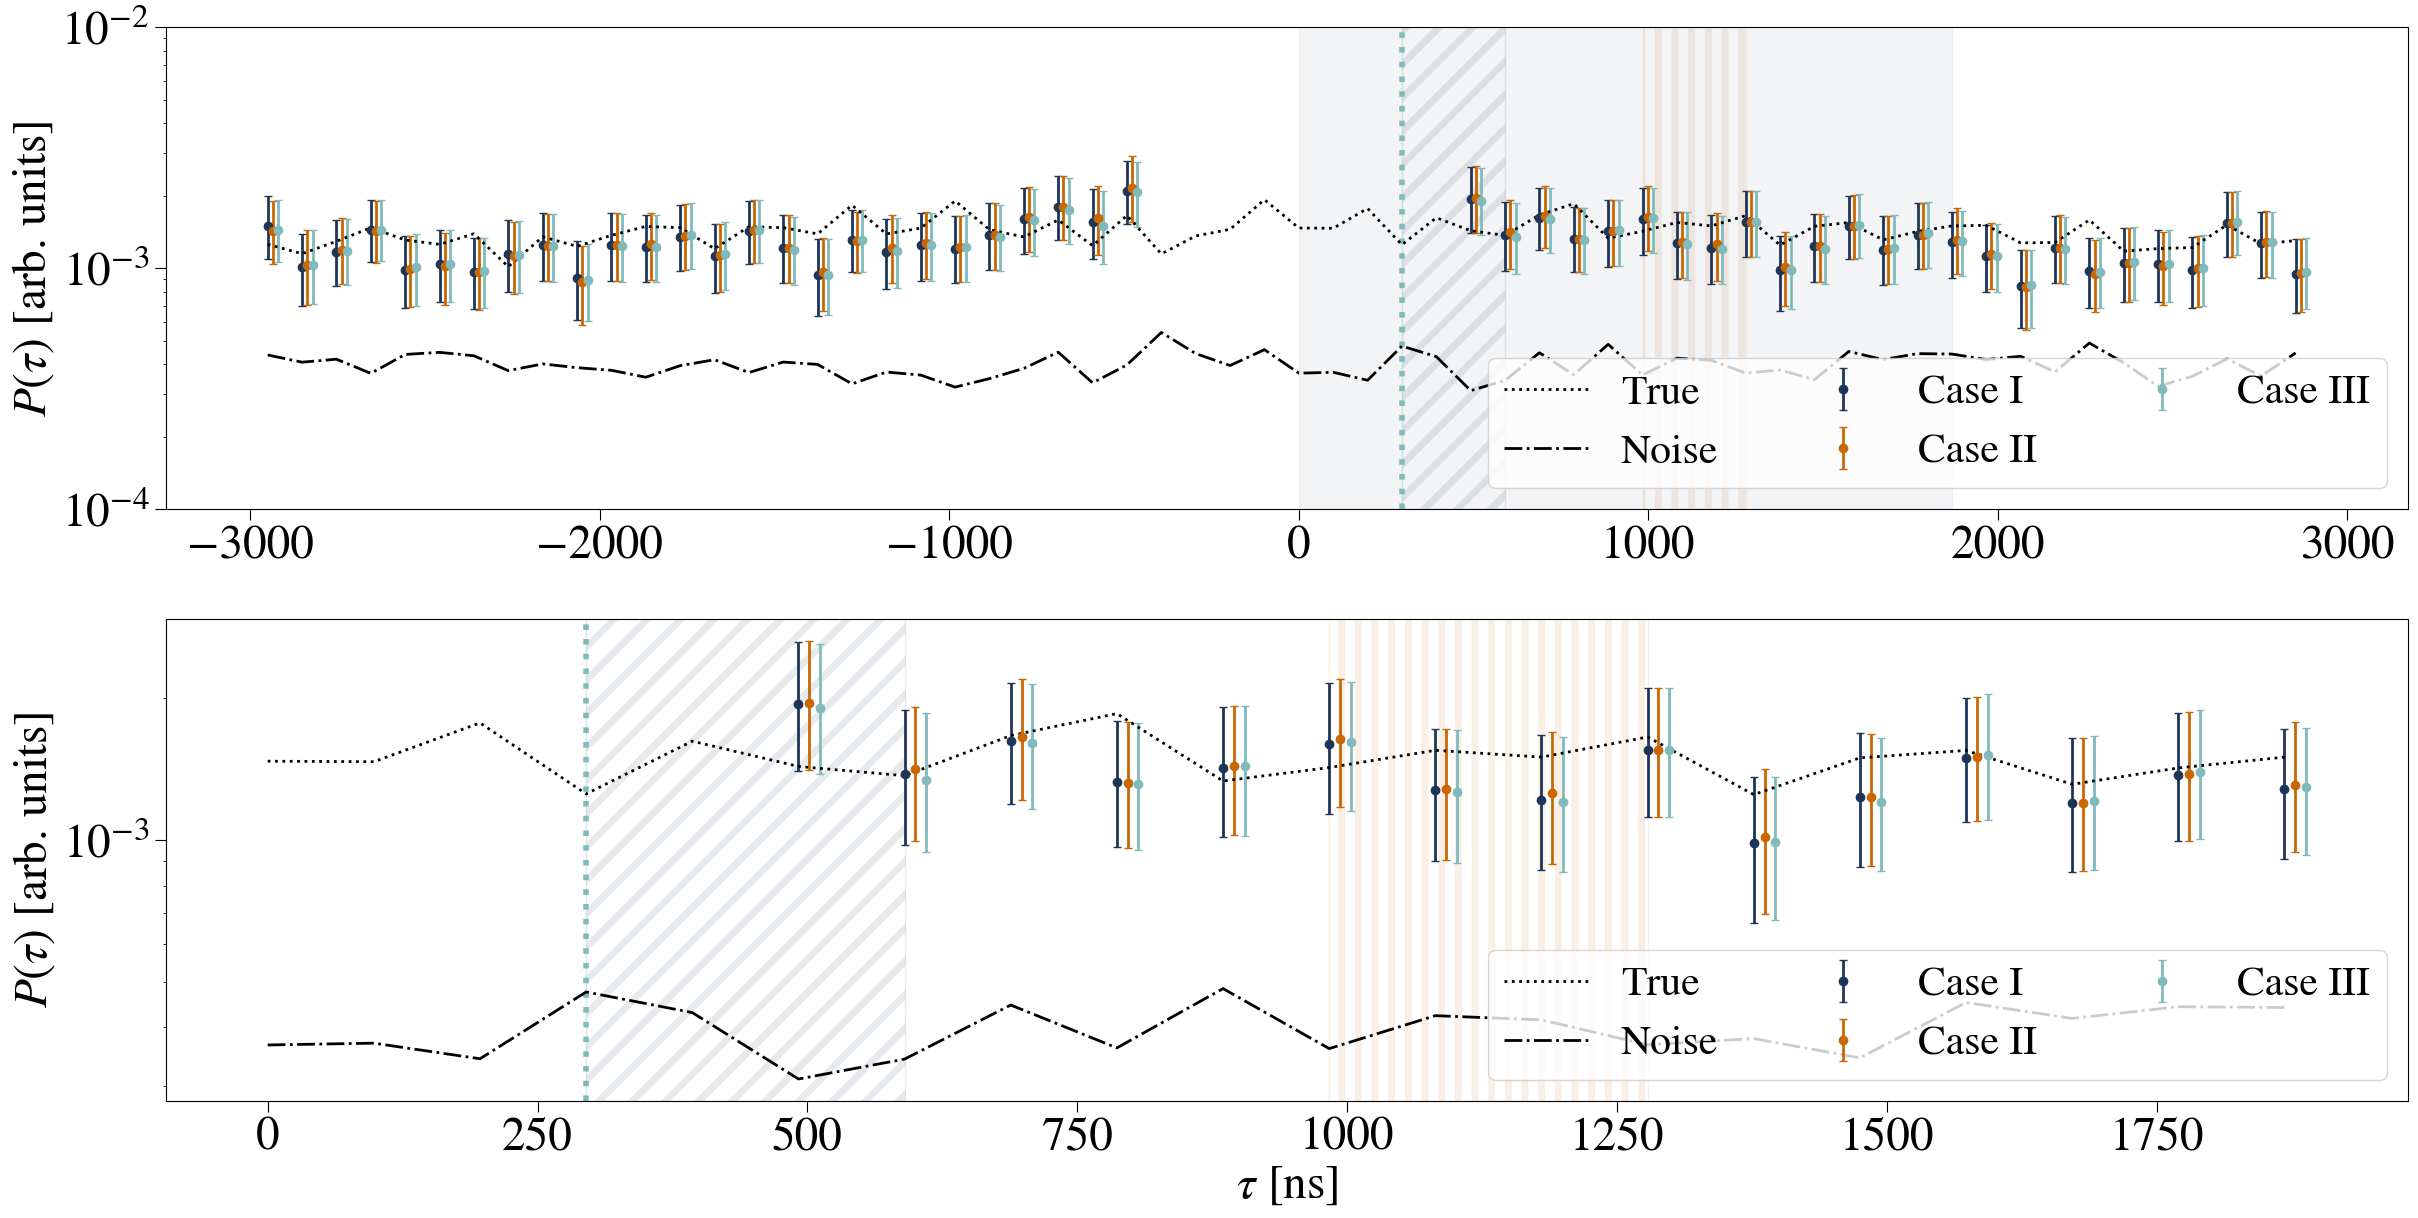

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

fig_labels_dps = ['I', 'II', 'III']
hatches = ['/', '|', '.']

for i, run_version in enumerate(run_version_arr):
    eor_true_i = np.load(result_dir + run_version + '/eor_true.npy')
    ps_sample_i = np.load(result_dir + run_version + '/dps-eor.npy')
    ln_post_i   = np.load(result_dir + run_version + '/ln-post.npy')
    ps_true_i   = calc_ps(eor_true_i[:Ntimes, :Nfreqs])

    sys_delays = delays[np.unique(dl_inds[i]) + int(Nfreqs / 2)].value

    if Nburn > 0:
        ps_sample_i = ps_sample_i[Nburn:]
        ln_post_i   = ln_post_i[Nburn:]

    dps_pwm    = np.average(ps_sample_i, weights=ln_post_i, axis=0)
    percentile = conf_interval / 2 + 50
    dps_ubound = np.percentile(ps_sample_i, percentile,       axis=0)
    dps_lbound = np.percentile(ps_sample_i, 100 - percentile, axis=0)
    dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

    ax[0].errorbar(
        delays.value + i * 15, dps_pwm, yerr=np.abs(dps_err),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )

    x0, x1 = np.min(sys_delays), np.max(sys_delays)
    ax[0].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)
    ax[1].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)

    if i == 2:
        for dl in sys_delays:
            ax[0].axvline(dl, ls='dotted', c=colors[i], lw=4)
            ax[1].axvline(dl, ls='dotted', c=colors[i], lw=4)

    ax[1].errorbar(
        delays[35:50].value + i * 10, dps_pwm[35:50], yerr=np.abs(dps_err[:, 35:50]),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )
    print(np.mean((dps_pwm - ps_true_i) / ps_true_i))

ps_true_ref = calc_ps(np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs])

ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].plot(delays[30:50], ps_true_ref[30:50], 'k:', label='True', lw=2)
ax[1].plot(delays[30:50], calc_ps(n.T)[30:50], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3, fontsize=30)
ax[1].set_yscale('log')

ax[0].plot(delays, ps_true_ref, 'k:', label='True', lw=2)
ax[0].plot(delays, calc_ps(n.T), 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3, fontsize=30)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-2)
ax[0].set_yscale('log')
ax[0].axvspan(delays[30].value, delays[49].value, facecolor=colors[0], ec=colors[0],alpha=0.05, zorder=0.1)

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()
plt.savefig(fig_dir + '/delay_power_spectrum_combined.pdf', bbox_inches='tight', dpi=300)

---
# Table 1: ESS and autocorrelation time

In [ ]:
for run_version in run_version_arr:
    print('Case:', run_version)
    b_sys = np.load(result_dir + run_version + '/b-sys.npy')
    taus  = emcee.autocorr.integrated_time(b_sys, c=5, tol=50, quiet=True, has_walkers=False)
    ess   = Niter / taus
    print('\n Taus: {}\nEss:{}\n'.format(taus, ess))

Case: low_dl_fr_0

 Taus: [698.45676808 608.53953469  92.27023448  77.7223783 ]
Ess:[ 143.17278401  164.32786089 1083.77312104 1286.63072583]

Case: high_dl_fr_0

 Taus: [9.04033747 7.49803835 7.59655271 9.23706956]
Ess:[11061.53396499 13336.82162025 13163.8657435  10825.94423975]

Case: low_dl_fr_20

 Taus: [452.66133458 423.27131603 188.2239657   58.67591911]
Ess:[ 220.91570974  236.25508324  531.28197372 1704.27666945]



---
# Figure 11: FG–systematics correlation (all cases)

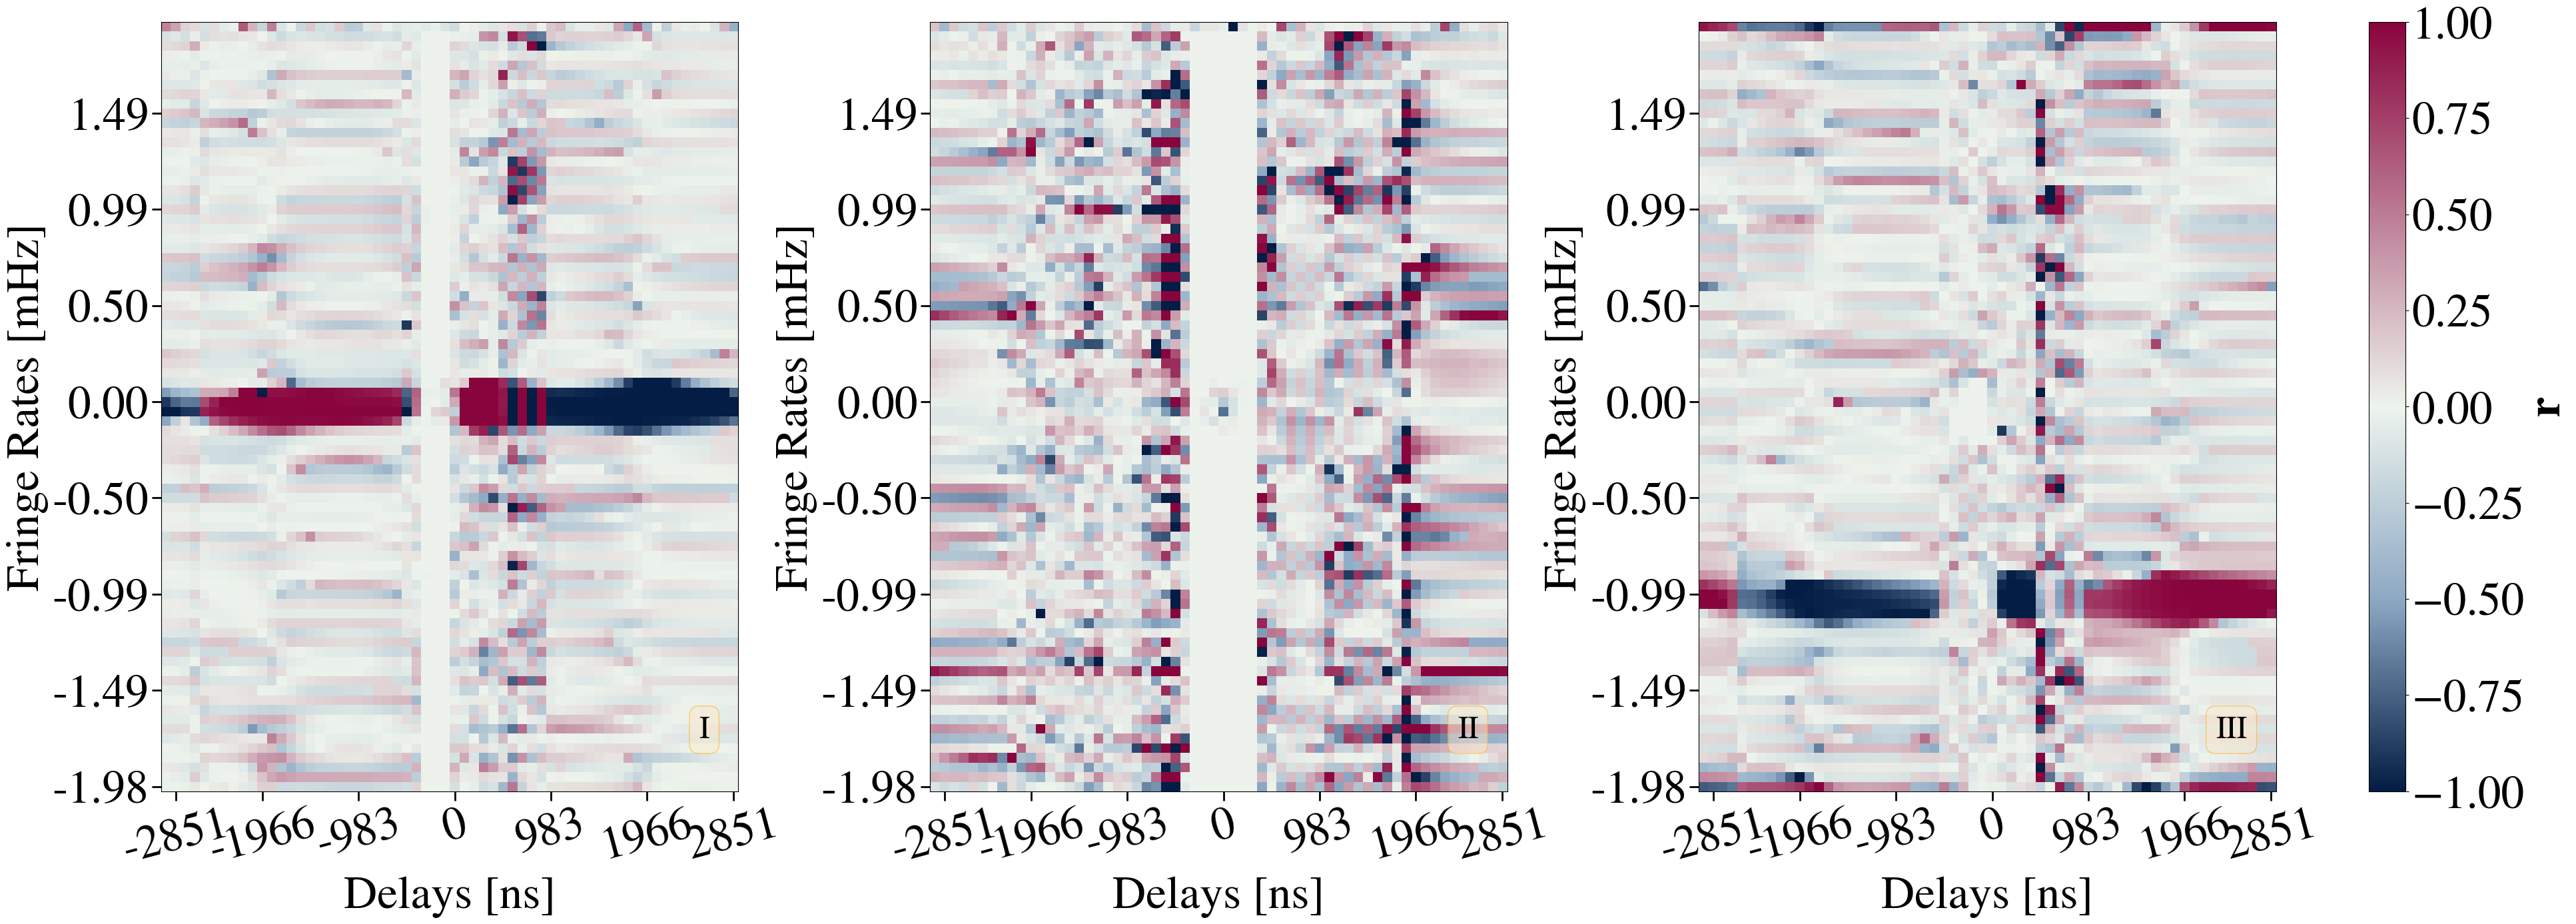

In [ ]:
fig = plt.figure(figsize=(45, 15))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    label_mode='all',
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

fig_labels_corr = ['I', 'II', 'III']
for i in range(3):
    im = axs[i].imshow(corr_maps[i][::-1, :].real, cmap=paper_map, origin='lower', vmin=-1, vmax=1)
    axs[i].text(0.95, 0.07, fig_labels_corr[i], bbox=bbox,
                transform=axs[i].transAxes, horizontalalignment='right')

cbar = axs.cbar_axes[0].colorbar(im)
cbar.set_label(r'$\mathbf{r}$', size=50)
cbar.ax.tick_params(labelsize=50)

for ax in axs:
    ax.set_xlabel('Delays [ns]', fontsize=50)
    ax.set_ylabel('Fringe Rates [mHz]', fontsize=50)
    ax.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=50)
    ax.set_xticks(xticklocs, labels=xticklabels_dl, rotation=15)
    ax.set_yticks(yticklocs, labels=yticklabels_fr)

plt.savefig(fig_dir + '/fg_sys._corr.pdf', bbox_inches='tight', dpi=300)

In [ ]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 19m 35.5s
